<div align="center">
    <h3>Aristotle University of Thessaloniki</h3>
    <h1>Analysis of Medical Images MedMNIST with CNN, Transfer Learning & Vision Transformers (Pytorch)</h1>
    <h3>Deep-Learning Winter Sem. 2025-2026</h3>
    <p>
        <b>Zisis Katsaros - 10666</b><br>
        <small>Prof.: P. Petrantonakis</small>
    </p>
</div>

## **0.** Description of Dataset ##

In [1]:
! pip install medmnist
! python &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.5 MB/s eta 0:00:00


In [2]:
import medmnist
from medmnist import OrganSMNIST
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms

# Define image to tensor transform 
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]) 
])

# Setup training, validation, and test datasets
train_dataset = OrganSMNIST(split="train", download=True, transform=data_transform)
val_dataset = OrganSMNIST(split="val", download=True, transform=data_transform)
test_dataset = OrganSMNIST(split="test", download=True, transform=data_transform)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 64
torch.manual_seed(42) 
train_data = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_data = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_data = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Print dataset info:
print(f"==================== Dataset Info ====================")
print(f" - Name: OrganSMNIST")

num_of_classes = len(train_dataset.info['label']) # get number of classes from dataset info
print(f" - Number of classes: {num_of_classes}")

images, labels = next(iter(train_data)) # get first batch of iterator
channels, rows, cols = images.shape[1], images.shape[2], images.shape[3] # get image characteristics
if channels == 1:
    print(f" - Image size: {rows}x{cols} (Grayscale)")
elif channels == 3:
    print(f" - Image size: {rows}x{cols} (RGB)")
else:
    print(f" - Image size: {rows}x{cols}")

# get training, validation, test and total samples
train_size = len(train_dataset)
val_size = len(val_dataset)
test_size = len(test_dataset)
num_samples = train_size + val_size + test_size

print(f" - Samples: {num_samples}")
print(f" - Training: {train_size}")
print(f" - Validation: {val_size}")
print(f" - Test: {test_size}")

100%|██████████| 16.5M/16.5M [00:30<00:00, 537kB/s]


==================== Dataset Info ====================
 - Name: OrganSMNIST
 - Number of classes: 11
 - Image size: 28x28 (Grayscale)
 - Samples: 25211
 - Training: 13932
 - Validation: 2452
 - Test: 8827


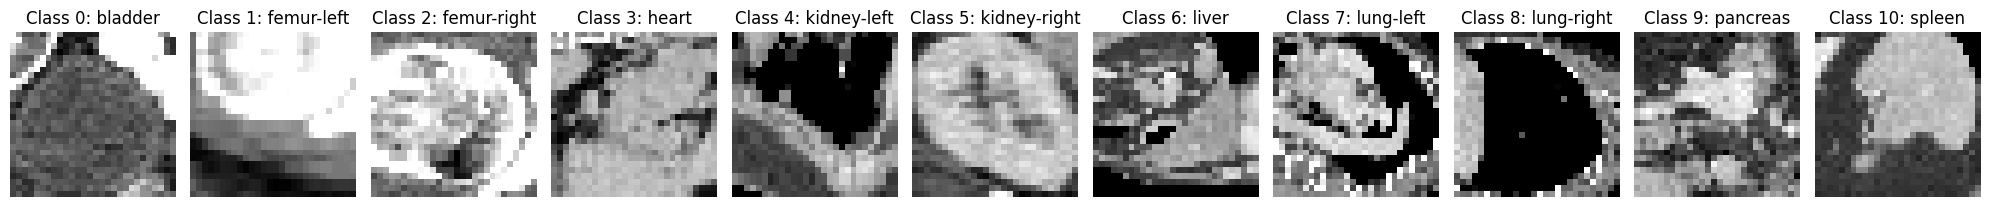

Class Distribution:
 - Class 0 (bladder): 8.24%
 - Class 1 (femur-left): 4.52%
 - Class 2 (femur-right): 4.41%
 - Class 3 (heart): 5.18%
 - Class 4 (kidney-left): 8.13%
 - Class 5 (kidney-right): 8.03%
 - Class 6 (liver): 24.86%
 - Class 7 (lung-left): 5.32%
 - Class 8 (lung-right): 5.76%
 - Class 9 (pancreas): 14.38%
 - Class 10 (spleen): 11.17%


In [3]:
# Visulaization and Class distribution

labels_dict = train_dataset.info['label'] # get lables dictionary from dataset info

fig, axes = plt.subplots(1, num_of_classes, figsize=(20, 3)) # create plot

classes = set()
num_of_samples_per_class = np.zeros(num_of_classes, dtype=int) # initialize samples per class counter 
images_dataset = OrganSMNIST(split="train", download=True, size=28) # load training dataset without transform

# iterate through the dataset
for i in range(len(images_dataset)):
    image, label = images_dataset[i]
    label = label.item()

    # plot each new class sample 
    if label not in classes:
        ax = axes[label]
        ax.imshow(image, cmap='gray')
        ax.set_title(f"Class {label}: {labels_dict[str(label)]}")
        ax.axis('off')

        classes.add(label)

    # count samples per class
    num_of_samples_per_class[label] += 1

# get distribution by dividing by total training samples
class_distribution = num_of_samples_per_class / train_size

plt.tight_layout()
plt.show()

print(f"Class Distribution:")
for i in range(num_of_classes):
    print(f" - Class {i} ({labels_dict[str(i)]}): {class_distribution[i] * 100:.2f}%")

### Train and Test Loops ###

In [4]:
# Training Loop:
def train_loop(model, dataloader, optimizer, criterion, device):
    model.train() # model in training mode

    total_loss = 0.0
    correct = 0
    total = 0

    # iterate through training batches
    for batch, (images, labels) in enumerate(dataloader):
        images = images.to(device) 
        labels = labels.squeeze().to(device)

        outputs = model(images) # forward pass
        loss = criterion(outputs, labels) # loss function
        total_loss += loss.item()

        optimizer.zero_grad() # zero the previous gradients
        loss.backward() # backpropagation
        optimizer.step() # update weights

        preds = outputs.argmax(dim=1) # get predicted class
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(dataloader), correct / total # return loss and accuracy

# Test Loop:
def test_loop(model, dataloader, criterion, device):
    model.eval() # model in evaluation mode

    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad(): # disable gradient calculation
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.squeeze().to(device)

            outputs = model(images) # forward pass
            loss = criterion(outputs, labels) # loss function
            total_loss += loss.item()

            preds = outputs.argmax(dim=1) # get predicted class
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy()) # store all predictions
            all_labels.extend(labels.cpu().numpy()) # store all true labels

    # return loss, accuracy, all predictions and all true labels
    return total_loss / len(dataloader), correct / total, np.array(all_preds), np.array(all_labels) 

### Functions used for Visualization ###

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# Loss, Accuracy, Confusion Matrix Plot 
def plot_loss_acc_confusion(train_losses, val_losses, train_accuracies, val_accuracies, test_acc,
                          targets, preds, labels_dict, model_name, batch_size, learning_rate, num_of_blocks=3, batch_norm=False, layer_norm=False,
                          dropout=0.0, weight_decay=0.0):
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.35, wspace=0.3)

    # Top-left: Loss curves
    ax_loss = fig.add_subplot(gs[0, 0])
    epochs = range(1, len(train_losses) + 1)
    ax_loss.plot(epochs, train_losses, 'b-', label='Training Loss')
    ax_loss.plot(epochs, val_losses, 'r-', label='Validation Loss')
    ax_loss.set_title('Loss over Epochs')
    ax_loss.set_xlabel('Epochs')
    ax_loss.set_ylabel('Loss')
    ax_loss.grid(True, alpha=0.2)
    ax_loss.legend(loc='best')

    # Top-right: Accuracy curves
    ax_acc = fig.add_subplot(gs[0, 1])
    ax_acc.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
    ax_acc.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
    ax_acc.set_title('Accuracy over Epochs')
    ax_acc.set_xlabel('Epochs')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_ylim(0, 1)
    ax_acc.grid(True, alpha=0.2)
    ax_acc.legend(loc='best')

    # Bottom-left: Confusion Matrix
    ax_cm = fig.add_subplot(gs[1, 0])
    confusion_mat = confusion_matrix(targets, preds)
    im = ax_cm.imshow(confusion_mat, interpolation='nearest', cmap=plt.cm.Blues)
    ax_cm.set_title('Confusion Matrix')
    fig.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)

    class_names = [labels_dict[str(i)] for i in range(len(labels_dict))]
    tick_marks = np.arange(len(class_names))
    ax_cm.set_xticks(tick_marks)
    ax_cm.set_xticklabels(class_names, rotation=45, ha='right')
    ax_cm.set_yticks(tick_marks)
    ax_cm.set_yticklabels(class_names)

    # Annotate counts
    max_val = confusion_mat.max() if confusion_mat.size else 0
    for i in range(confusion_mat.shape[0]):
        for j in range(confusion_mat.shape[1]):
            val = confusion_mat[i, j]
            ax_cm.text(j, i, val, ha='center', va='center',
                       color='white' if val > max_val / 2 else 'black', fontsize=9)

    # Bottom-right: Information 
    ax_text = fig.add_subplot(gs[1, 1])
    ax_text.axis('off')
    ax_text.set_title('Information', fontsize=14, fontweight='bold')

    if "MyCNN" in model_name:
        lines = [
            f" - Model: {model_name}",
            f" - Num. of Blocks: {num_of_blocks}",
            f" - Batch Size: {batch_size}",
            f" - BatchNorm: {'On' if batch_norm else 'Off'}",
            f" - LayerNorm: {'On' if layer_norm else 'Off'}",
            f" - Dropout: {'Off' if dropout == 0.0 else f'{dropout*100:.0f}%'}",
            f" - Weight Decay: {weight_decay}",
            f" - Learning Rate: {learning_rate}",
            f" >>> Test Accuracy: {test_acc*100:.2f}%"
        ]

    else:
        lines = [
            f" - Model: {model_name}",
            f" - Batch Size: {batch_size}",
            f" - Learning Rate: {learning_rate}",
            f" >>> Test Accuracy: {test_acc*100:.2f}%"
        ]

    y0 = 0.9
    dy = 0.12
    for i, line in enumerate(lines):
        ax_text.text(0.0, y0 - i * dy, line, transform=ax_text.transAxes, fontsize=10, va='top')

    plt.tight_layout()
    plt.show()


# Loss and Accuracy Plot
def plot_loss_acc_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.2)
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.2)
    plt.legend()

    plt.tight_layout()
    plt.show()

# Confusion Matrix Plot
def plot_confusion_matrix(targets, preds, labels):
    confusion_mat = confusion_matrix(targets, preds)
    class_names = [labels[str(i)] for i in range(len(labels))]

    plt.figure(figsize=(8, 6))
    plt.imshow(confusion_mat, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = range(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

     # Annotate counts
    max_val = confusion_mat.max() if confusion_mat.size else 0
    for i in range(confusion_mat.shape[0]):
        for j in range(confusion_mat.shape[1]):
            val = confusion_mat[i, j]
            plt.text(j, i, val, ha='center', va='center',
                       color='white' if val > max_val / 2 else 'black', fontsize=9)
            
    plt.show()

## **1.** CNN from scratch ##

### 1.1 MyCNN ###

In [6]:
import numpy as np
import torch
from torch import nn

class MyCNN(nn.Module):
    def __init__(self, img_size, num_of_channels, num_of_classes, num_of_filters=32, num_of_blocks=3, batch_norm=False, 
                 layer_norm=False, dropout_prob=0.0):
        super(MyCNN, self).__init__()

        self.blocks = nn.ModuleList() # list to hold convolutional blocks

        in_channels = num_of_channels # initial input channel size = number of image channels
        out_channels = num_of_filters # initial output channel size = number of filters

        # Convolutional Blocks: Conv2d -> (BatchNorm) -> ReLU -> MaxPool2d -> (LayerNorm)
        for i in range(num_of_blocks):
            self.blocks.append(nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels) if batch_norm else nn.Identity(),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2),
                nn.LayerNorm([out_channels, img_size // (2 ** (i + 1)), img_size // (2 ** (i + 1))]) if layer_norm else nn.Identity()
            ))
            in_channels = out_channels # update input channels for next block
            out_channels *= 2  # double output channels for next block 

            # Calculate final image size 
            final_img_size = img_size // (2 ** num_of_blocks) # halfed for each block due to MaxPool2d

            if final_img_size < 1:
                print(f"Image size too small for the number of blocks.") 

            self.flatten_dim = in_channels * final_img_size ** 2     

            # Fully Connected Layer:
            self.dropout = nn.Dropout(dropout_prob) if dropout_prob > 0 else nn.Identity()
            self.fc1 = nn.Linear(self.flatten_dim, num_of_classes)     

    def forward(self, x):
        for block in self.blocks:
            x = block(x) # pass through each convolutional block

        x = x.flatten(1)

        x = self.dropout(x) 
        x = self.fc1(x)
        return x

### 1.2 Training with different Hyperparameter Values ###

#### I. Default: 3 Blocks, Batch size: 64, learning rate: 1e-3, 30 Epochs ####

In [7]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows # square images

MyCNN_default = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes) 
MyCNN_default.to(device)
# print(MyCNN_default)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_default.parameters(), lr=learning_rate)

# Initialize metrix lists
train_losses_default = []
val_losses_default = []
train_accuracies_default = []
val_accuracies_default = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_default, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_default, val_data, criterion, device)

    # Store metrics
    train_losses_default.append(train_loss)
    val_losses_default.append(val_loss)
    train_accuracies_default.append(train_acc)
    val_accuracies_default.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_default, _, _ = test_loop(MyCNN_default, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_default*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.0942, Train Acc: 59.40%
Val Loss: 0.5014, Val Acc: 81.24%

Epoch 5
-------------------------------
Train Loss: 0.2969, Train Acc: 87.94%
Val Loss: 0.3994, Val Acc: 85.85%

Epoch 10
-------------------------------
Train Loss: 0.1233, Train Acc: 94.83%
Val Loss: 0.3936, Val Acc: 88.30%

Epoch 15
-------------------------------
Train Loss: 0.0602, Train Acc: 97.37%
Val Loss: 0.6592, Val Acc: 86.30%

Epoch 20
-------------------------------
Train Loss: 0.0493, Train Acc: 97.73%
Val Loss: 0.5970, Val Acc: 87.56%

Epoch 25
-------------------------------
Train Loss: 0.0397, Train Acc: 98.26%
Val Loss: 0.6573, Val Acc: 87.68%

Epoch 30
-------------------------------
Train Loss: 0.0209, Train Acc: 99.22%
Val Loss: 0.7509, Val Acc: 87.48%

==================== Training complete ====================
>>> Test Accuracy: 74.94%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


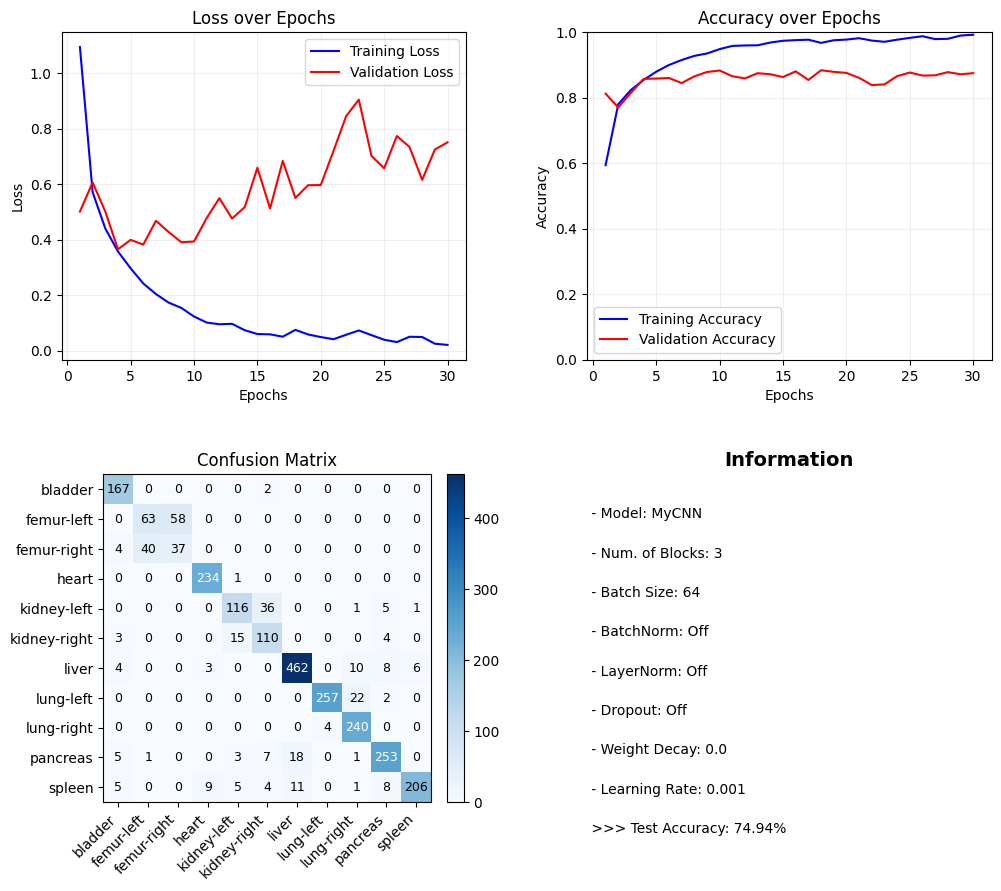

In [12]:
# Visualization
plot_loss_acc_confusion(train_losses_default, val_losses_default, train_accuracies_default, val_accuracies_default, test_acc_default,
                          targets, preds, labels_dict,model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate)

#### II. 4 Blocks ####

In [13]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows # square images

MyCNN_4Blocks = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=4) 
MyCNN_4Blocks.to(device)
# print(MyCNN_4Blocks)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_4Blocks.parameters(), lr=learning_rate)

# Initialize metrix lists
train_losses_4Blocks = []
val_losses_4Blocks = []
train_accuracies_4Blocks = []
val_accuracies_4Blocks = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_4Blocks, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_4Blocks, val_data, criterion, device)

    # Store metrics
    train_losses_4Blocks.append(train_loss)
    val_losses_4Blocks.append(val_loss)
    train_accuracies_4Blocks.append(train_acc)
    val_accuracies_4Blocks.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_4Blocks, _, _ = test_loop(MyCNN_4Blocks, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_4Blocks*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.0714, Train Acc: 60.26%
Val Loss: 0.5482, Val Acc: 79.16%

Epoch 5
-------------------------------
Train Loss: 0.2316, Train Acc: 89.89%
Val Loss: 0.4282, Val Acc: 86.58%

Epoch 10
-------------------------------
Train Loss: 0.0804, Train Acc: 95.84%
Val Loss: 0.6261, Val Acc: 86.62%

Epoch 15
-------------------------------
Train Loss: 0.0586, Train Acc: 97.04%
Val Loss: 0.6197, Val Acc: 87.11%

Epoch 20
-------------------------------
Train Loss: 0.0687, Train Acc: 97.06%
Val Loss: 0.5316, Val Acc: 87.77%

Epoch 25
-------------------------------
Train Loss: 0.0346, Train Acc: 98.36%
Val Loss: 0.7755, Val Acc: 88.01%

Epoch 30
-------------------------------
Train Loss: 0.0381, Train Acc: 98.49%
Val Loss: 0.7385, Val Acc: 87.03%

==================== Training complete ====================
>>> Test Accuracy: 74.88%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


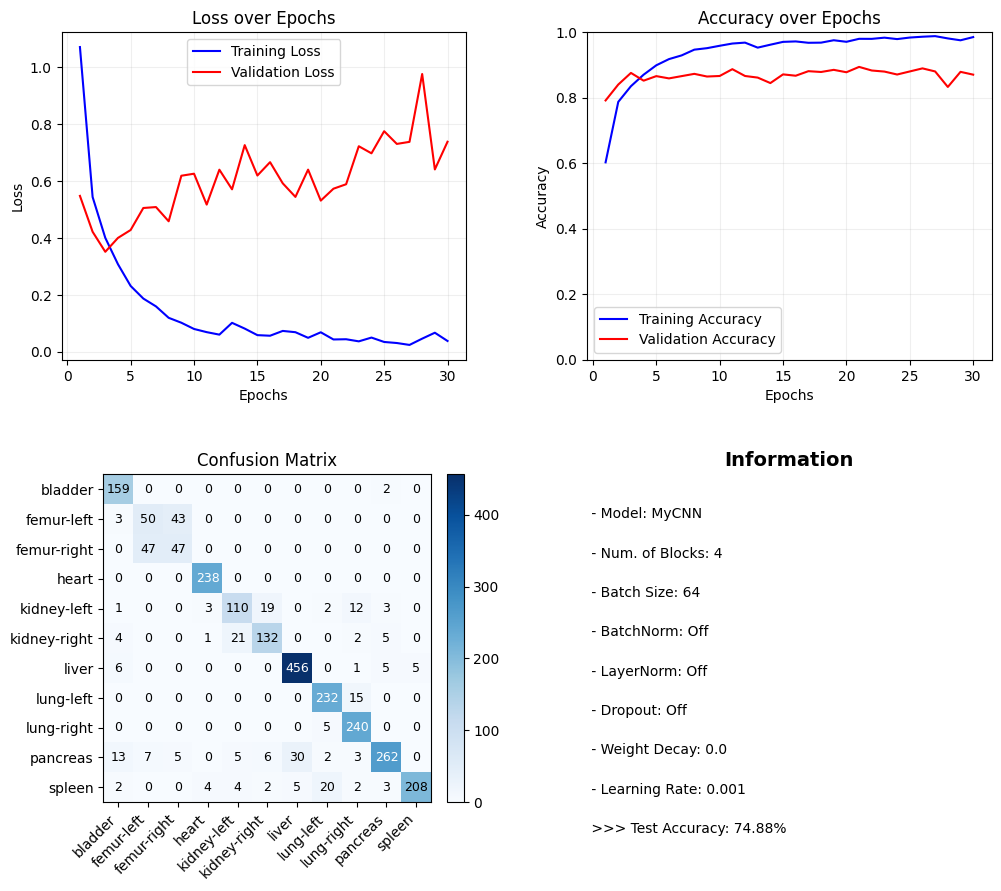

In [15]:
# Visualization
plot_loss_acc_confusion(train_losses_4Blocks, val_losses_4Blocks, train_accuracies_4Blocks, val_accuracies_4Blocks, test_acc_4Blocks,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=4)

#### III. Batch Normalization: 3 Blocks, learning rate: 5e-4, 30 Epochs, batch_norm on ####

In [18]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows # square images

MyCNN_BatchNorm = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3, batch_norm=True) 
MyCNN_BatchNorm.to(device)
# print(MyCNN_BatchNorm)

epochs = 30
learning_rate = 5e-4
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_BatchNorm.parameters(), lr=learning_rate)

# Initialize metrix lists
train_losses_BatchNorm = []
val_losses_BatchNorm = []
train_accuracies_BatchNorm = []
val_accuracies_BatchNorm = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_BatchNorm, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_BatchNorm, val_data, criterion, device)

    # Store metrics
    train_losses_BatchNorm.append(train_loss)
    val_losses_BatchNorm.append(val_loss)
    train_accuracies_BatchNorm.append(train_acc)
    val_accuracies_BatchNorm.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_BatchNorm, _, _ = test_loop(MyCNN_BatchNorm, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_BatchNorm*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 0.8533, Train Acc: 69.74%
Val Loss: 0.4602, Val Acc: 81.77%

Epoch 5
-------------------------------
Train Loss: 0.2151, Train Acc: 91.96%
Val Loss: 0.3016, Val Acc: 88.25%

Epoch 10
-------------------------------
Train Loss: 0.0801, Train Acc: 97.57%
Val Loss: 0.2717, Val Acc: 89.19%

Epoch 15
-------------------------------
Train Loss: 0.0375, Train Acc: 98.95%
Val Loss: 0.3176, Val Acc: 88.21%

Epoch 20
-------------------------------
Train Loss: 0.0210, Train Acc: 99.62%
Val Loss: 0.3469, Val Acc: 88.99%

Epoch 25
-------------------------------
Train Loss: 0.0051, Train Acc: 99.96%
Val Loss: 0.3286, Val Acc: 89.93%

Epoch 30
-------------------------------
Train Loss: 0.0015, Train Acc: 100.00%
Val Loss: 0.3619, Val Acc: 89.40%

==================== Training complete ====================
>>> Test Accuracy: 75.89%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


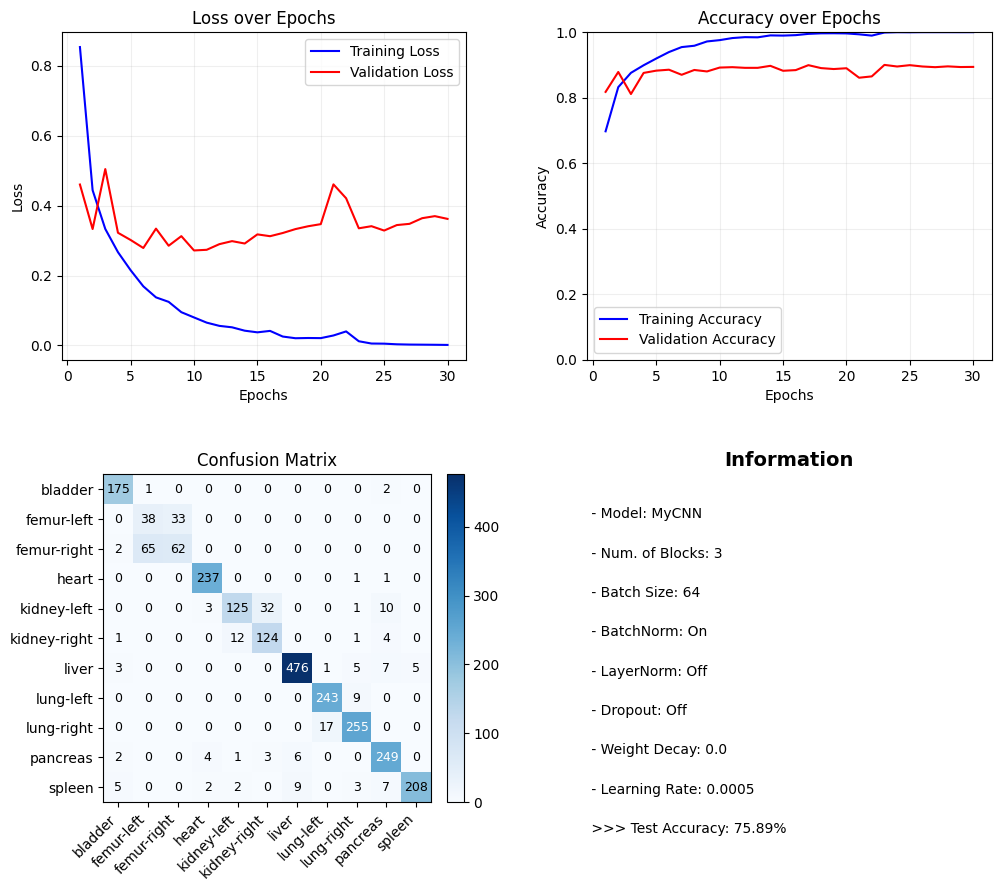

In [19]:
# Visualization
plot_loss_acc_confusion(train_losses_BatchNorm, val_losses_BatchNorm, train_accuracies_BatchNorm, val_accuracies_BatchNorm, test_acc_BatchNorm,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, batch_norm=True)

#### IV. Layer Normalization: 3 Blocks, learning rate: 5e-4, 30 Epochs, layer_norm on ####

In [20]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows # square images

MyCNN_LayerNorm = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3, layer_norm=True) 
MyCNN_LayerNorm.to(device)
# print(MyCNN_LayerNorm)

epochs = 30
learning_rate = 5e-4
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_LayerNorm.parameters(), lr=learning_rate)

# Initialize metrix lists
train_losses_LayerNorm = []
val_losses_LayerNorm = []
train_accuracies_LayerNorm = []
val_accuracies_LayerNorm = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_LayerNorm, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_LayerNorm, val_data, criterion, device)

    # Store metrics
    train_losses_LayerNorm.append(train_loss)
    val_losses_LayerNorm.append(val_loss)
    train_accuracies_LayerNorm.append(train_acc)
    val_accuracies_LayerNorm.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_LayerNorm, _, _ = test_loop(MyCNN_LayerNorm, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_LayerNorm*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 0.8009, Train Acc: 71.36%
Val Loss: 0.3903, Val Acc: 85.24%

Epoch 5
-------------------------------
Train Loss: 0.1054, Train Acc: 96.48%
Val Loss: 0.3054, Val Acc: 88.13%

Epoch 10
-------------------------------
Train Loss: 0.0293, Train Acc: 99.20%
Val Loss: 0.3091, Val Acc: 89.36%

Epoch 15
-------------------------------
Train Loss: 0.0080, Train Acc: 99.90%
Val Loss: 0.3290, Val Acc: 88.78%

Epoch 20
-------------------------------
Train Loss: 0.0074, Train Acc: 99.78%
Val Loss: 0.3355, Val Acc: 89.11%

Epoch 25
-------------------------------
Train Loss: 0.0008, Train Acc: 100.00%
Val Loss: 0.3655, Val Acc: 89.68%

Epoch 30
-------------------------------
Train Loss: 0.0003, Train Acc: 100.00%
Val Loss: 0.3785, Val Acc: 89.76%

==================== Training complete ====================
>>> Test Accuracy: 76.64%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


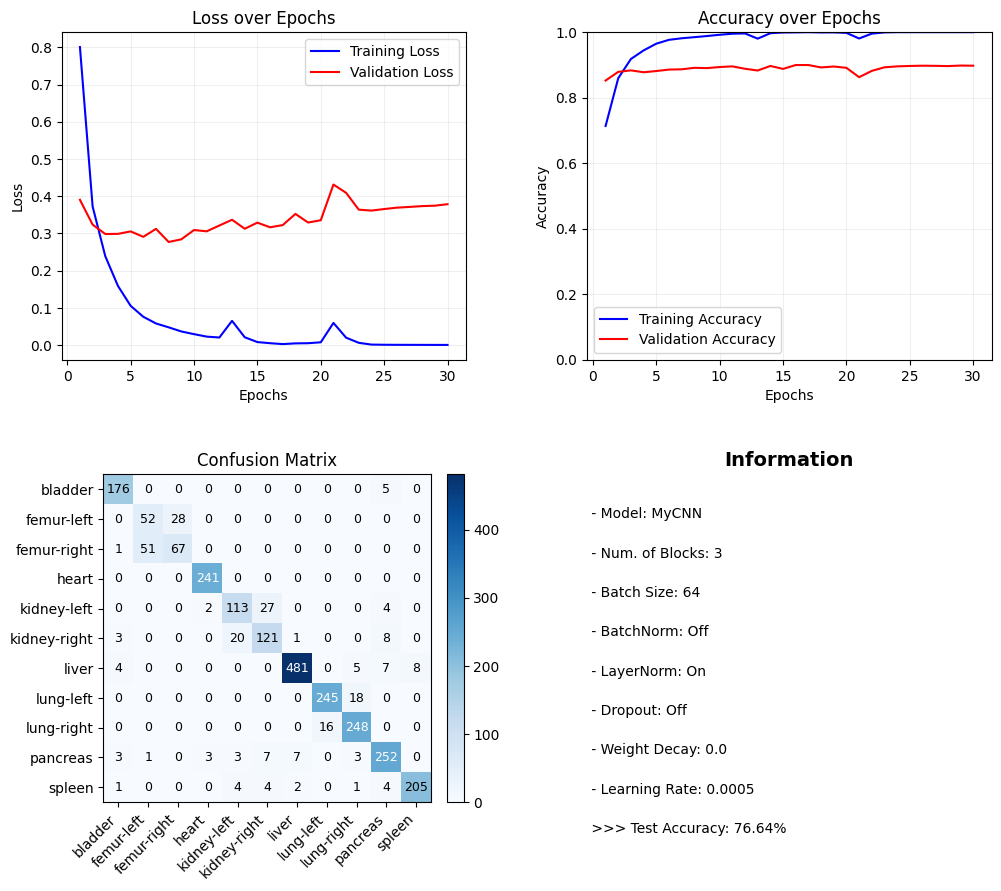

In [22]:
# Visualization
plot_loss_acc_confusion(train_losses_LayerNorm, val_losses_LayerNorm, train_accuracies_LayerNorm, val_accuracies_LayerNorm, test_acc_LayerNorm,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, layer_norm=True)

#### V. Dropout 1: 3 Blocks, learning rate: 1e-3, 30 Epochs, dropout_prob: 20% ####

In [23]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows # square images

MyCNN_Drop1 = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3, dropout_prob=0.2) 
MyCNN_Drop1.to(device)
# print(MyCNN_Drop1)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_Drop1.parameters(), lr=learning_rate)

# Initialize metrix lists
train_losses_Drop1 = []
val_losses_Drop1 = []
train_accuracies_Drop1 = []
val_accuracies_Drop1 = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_Drop1, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_Drop1, val_data, criterion, device)

    # Store metrics
    train_losses_Drop1.append(train_loss)
    val_losses_Drop1.append(val_loss)
    train_accuracies_Drop1.append(train_acc)
    val_accuracies_Drop1.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_Drop1, _, _ = test_loop(MyCNN_Drop1, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_Drop1*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.1242, Train Acc: 58.43%
Val Loss: 0.5024, Val Acc: 82.14%

Epoch 5
-------------------------------
Train Loss: 0.3518, Train Acc: 85.62%
Val Loss: 0.3716, Val Acc: 86.75%

Epoch 10
-------------------------------
Train Loss: 0.1926, Train Acc: 91.82%
Val Loss: 0.3729, Val Acc: 87.15%

Epoch 15
-------------------------------
Train Loss: 0.1340, Train Acc: 94.14%
Val Loss: 0.3805, Val Acc: 88.38%

Epoch 20
-------------------------------
Train Loss: 0.0971, Train Acc: 95.54%
Val Loss: 0.3755, Val Acc: 88.54%

Epoch 25
-------------------------------
Train Loss: 0.0754, Train Acc: 96.67%
Val Loss: 0.4437, Val Acc: 87.93%

Epoch 30
-------------------------------
Train Loss: 0.0653, Train Acc: 97.16%
Val Loss: 0.6130, Val Acc: 85.52%

==================== Training complete ====================
>>> Test Accuracy: 74.91%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


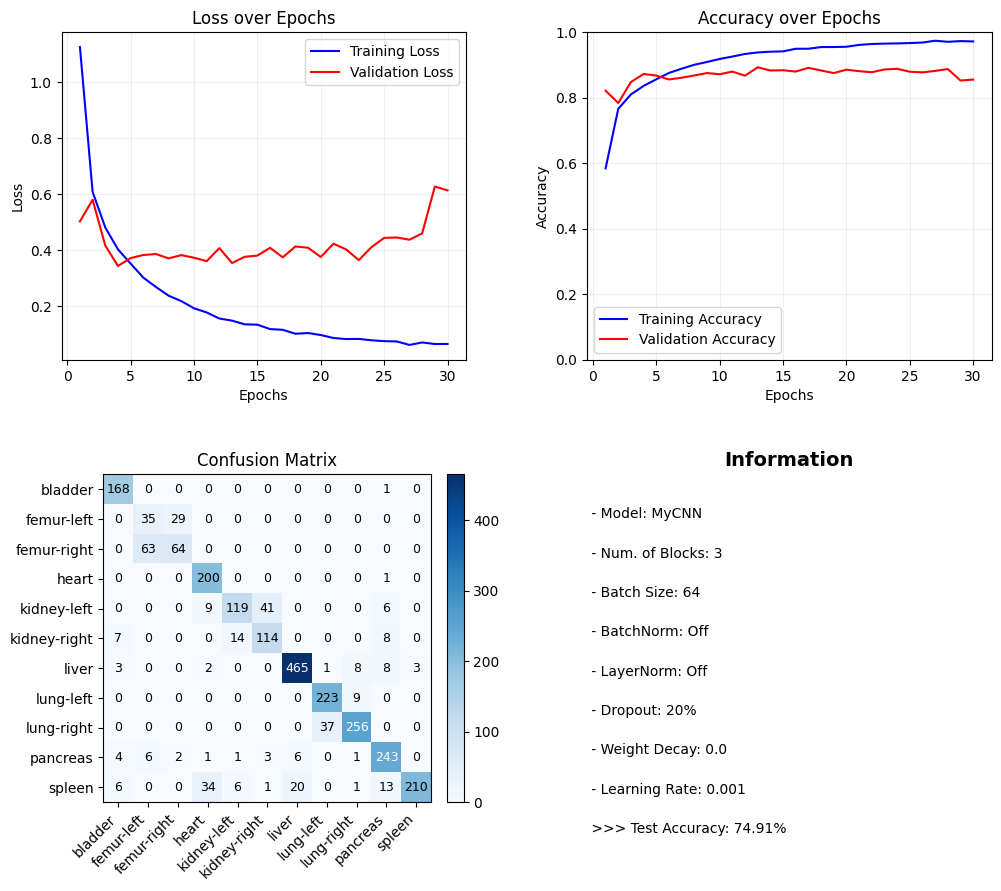

In [24]:
# Visualization
plot_loss_acc_confusion(train_losses_Drop1, val_losses_Drop1, train_accuracies_Drop1, val_accuracies_Drop1, test_acc_Drop1,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, dropout=0.2)

#### VI. Dropout 2: 3 Blocks, learning rate: 1e-3, 30 Epochs, dropout_prob: 50% ####

In [25]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows  # square images

MyCNN_Drop2 = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3, dropout_prob=0.5)
MyCNN_Drop2.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_Drop2.parameters(), lr=learning_rate)

# Initialize metrics lists
train_losses_Drop2 = []
val_losses_Drop2 = []
train_accuracies_Drop2 = []
val_accuracies_Drop2 = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_Drop2, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_Drop2, val_data, criterion, device)

    # Store metrics
    train_losses_Drop2.append(train_loss)
    val_losses_Drop2.append(val_loss)
    train_accuracies_Drop2.append(train_acc)
    val_accuracies_Drop2.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_Drop2, _, _ = test_loop(MyCNN_Drop2, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_Drop2*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.1980, Train Acc: 55.94%
Val Loss: 0.5666, Val Acc: 79.00%

Epoch 5
-------------------------------
Train Loss: 0.4466, Train Acc: 81.84%
Val Loss: 0.3387, Val Acc: 86.70%

Epoch 10
-------------------------------
Train Loss: 0.2964, Train Acc: 87.78%
Val Loss: 0.2947, Val Acc: 88.50%

Epoch 15
-------------------------------
Train Loss: 0.2260, Train Acc: 90.52%
Val Loss: 0.3008, Val Acc: 88.34%

Epoch 20
-------------------------------
Train Loss: 0.1749, Train Acc: 92.54%
Val Loss: 0.3027, Val Acc: 88.74%

Epoch 25
-------------------------------
Train Loss: 0.1453, Train Acc: 93.81%
Val Loss: 0.3225, Val Acc: 88.74%

Epoch 30
-------------------------------
Train Loss: 0.1175, Train Acc: 94.93%
Val Loss: 0.3390, Val Acc: 88.95%

==================== Training complete ====================
>>> Test Accuracy: 77.55%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


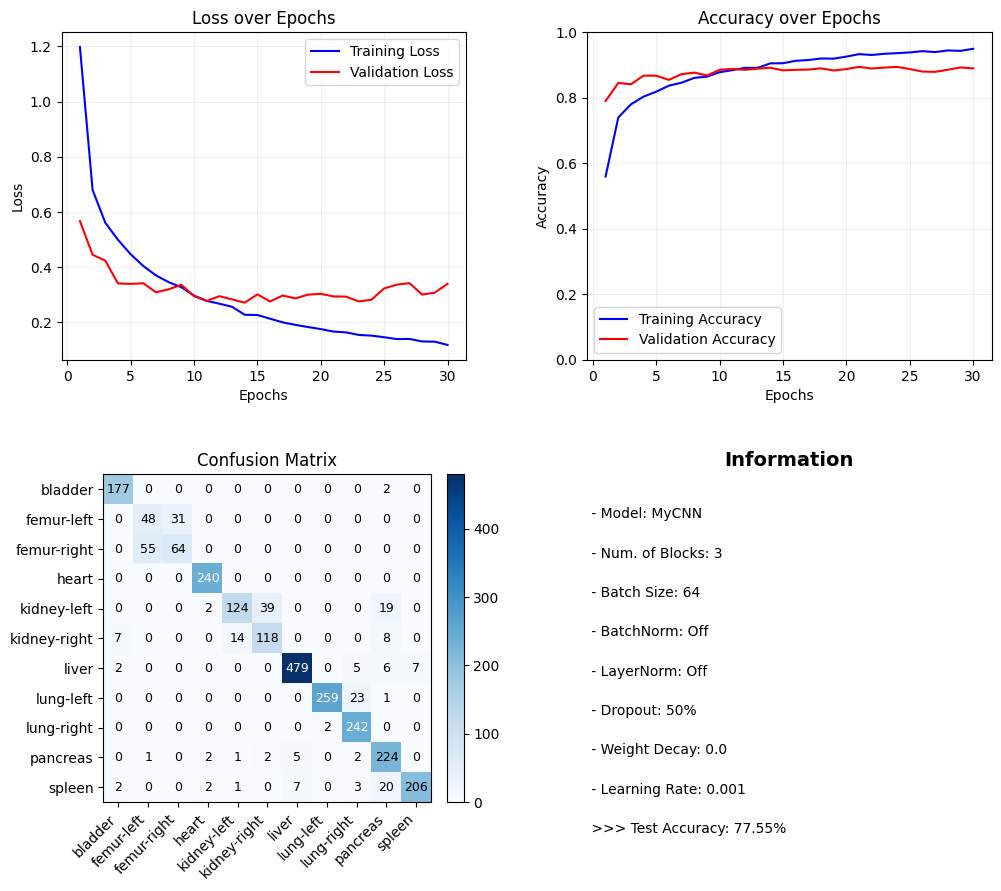

In [26]:
# Visualization
plot_loss_acc_confusion(train_losses_Drop2, val_losses_Drop2, train_accuracies_Drop2, val_accuracies_Drop2, test_acc_Drop2,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, dropout=0.5)

#### VII. Dropout 3: 3 Blocks, learning rate: 1e-3, 30 Epochs, dropout_prob: 70% ####

In [27]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows  # square images

MyCNN_Drop3 = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3, dropout_prob=0.7)
MyCNN_Drop3.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_Drop3.parameters(), lr=learning_rate)

# Initialize metrics lists
train_losses_Drop3 = []
val_losses_Drop3 = []
train_accuracies_Drop3 = []
val_accuracies_Drop3 = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_Drop3, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_Drop3, val_data, criterion, device)

    # Store metrics
    train_losses_Drop3.append(train_loss)
    val_losses_Drop3.append(val_loss)
    train_accuracies_Drop3.append(train_acc)
    val_accuracies_Drop3.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_Drop3, _, _ = test_loop(MyCNN_Drop3, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_Drop3*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.2953, Train Acc: 52.45%
Val Loss: 0.6451, Val Acc: 75.49%

Epoch 5
-------------------------------
Train Loss: 0.5348, Train Acc: 79.10%
Val Loss: 0.3553, Val Acc: 85.52%

Epoch 10
-------------------------------
Train Loss: 0.4005, Train Acc: 83.50%
Val Loss: 0.2944, Val Acc: 87.72%

Epoch 15
-------------------------------
Train Loss: 0.3144, Train Acc: 86.84%
Val Loss: 0.2608, Val Acc: 89.03%

Epoch 20
-------------------------------
Train Loss: 0.2719, Train Acc: 88.52%
Val Loss: 0.2445, Val Acc: 90.09%

Epoch 25
-------------------------------
Train Loss: 0.2364, Train Acc: 90.18%
Val Loss: 0.2597, Val Acc: 90.13%

Epoch 30
-------------------------------
Train Loss: 0.2100, Train Acc: 91.04%
Val Loss: 0.2497, Val Acc: 90.17%

==================== Training complete ====================
>>> Test Accuracy: 78.58%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


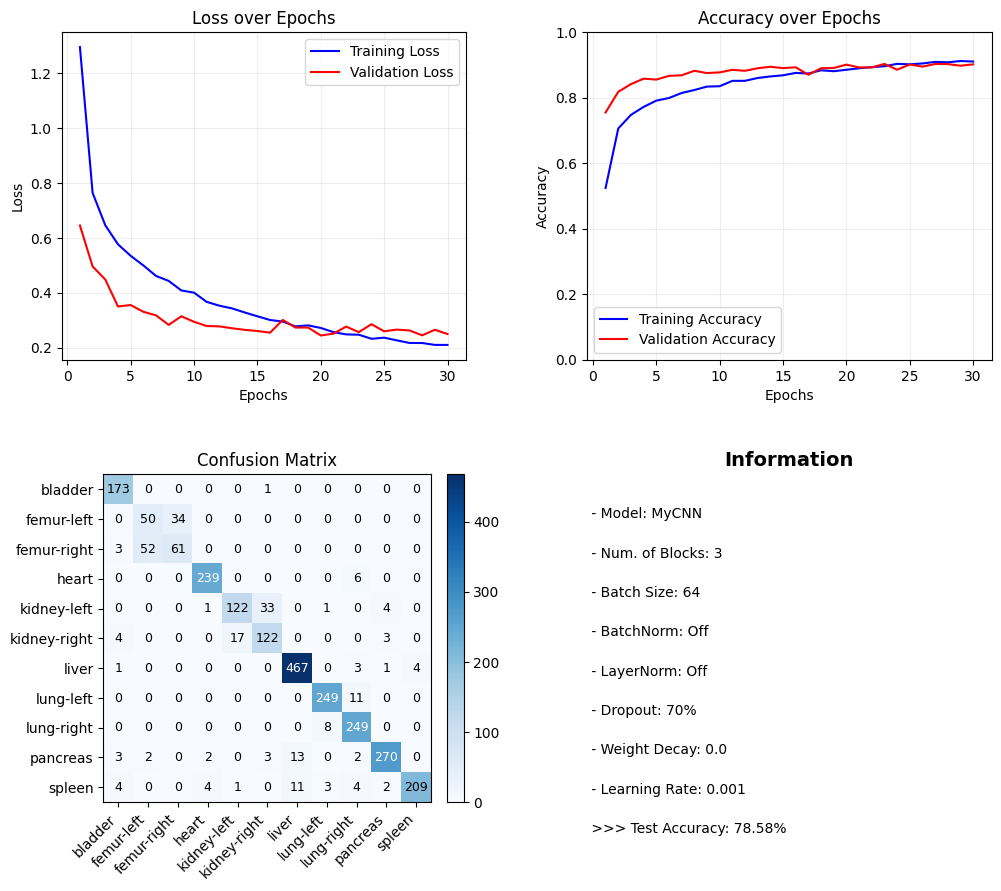

In [28]:
# Visualization
plot_loss_acc_confusion(train_losses_Drop3, val_losses_Drop3, train_accuracies_Drop3, val_accuracies_Drop3, test_acc_Drop3,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, dropout=0.7)

#### VIII. Weight Decay 1: 3 Blocks, learning rate: 1e-3, 30 Epochs, weight_decay: 1e-4 ####

In [29]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows  # square images

MyCNN_WD1 = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3)
MyCNN_WD1.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
weight_decay = 1e-4
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_WD1.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Initialize metrics lists
train_losses_WD1 = []
val_losses_WD1 = []
train_accuracies_WD1 = []
val_accuracies_WD1 = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_WD1, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_WD1, val_data, criterion, device)

    # Store metrics
    train_losses_WD1.append(train_loss)
    val_losses_WD1.append(val_loss)
    train_accuracies_WD1.append(train_acc)
    val_accuracies_WD1.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_WD1, _, _ = test_loop(MyCNN_WD1, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_WD1*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.0953, Train Acc: 59.34%
Val Loss: 0.5052, Val Acc: 80.91%

Epoch 5
-------------------------------
Train Loss: 0.2951, Train Acc: 88.01%
Val Loss: 0.3936, Val Acc: 85.81%

Epoch 10
-------------------------------
Train Loss: 0.1228, Train Acc: 94.82%
Val Loss: 0.4387, Val Acc: 86.75%

Epoch 15
-------------------------------
Train Loss: 0.0794, Train Acc: 96.53%
Val Loss: 0.4716, Val Acc: 87.60%

Epoch 20
-------------------------------
Train Loss: 0.0636, Train Acc: 97.23%
Val Loss: 0.6347, Val Acc: 86.34%

Epoch 25
-------------------------------
Train Loss: 0.0541, Train Acc: 97.64%
Val Loss: 0.6387, Val Acc: 85.85%

Epoch 30
-------------------------------
Train Loss: 0.0391, Train Acc: 98.41%
Val Loss: 0.6871, Val Acc: 86.30%

==================== Training complete ====================
>>> Test Accuracy: 74.59%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


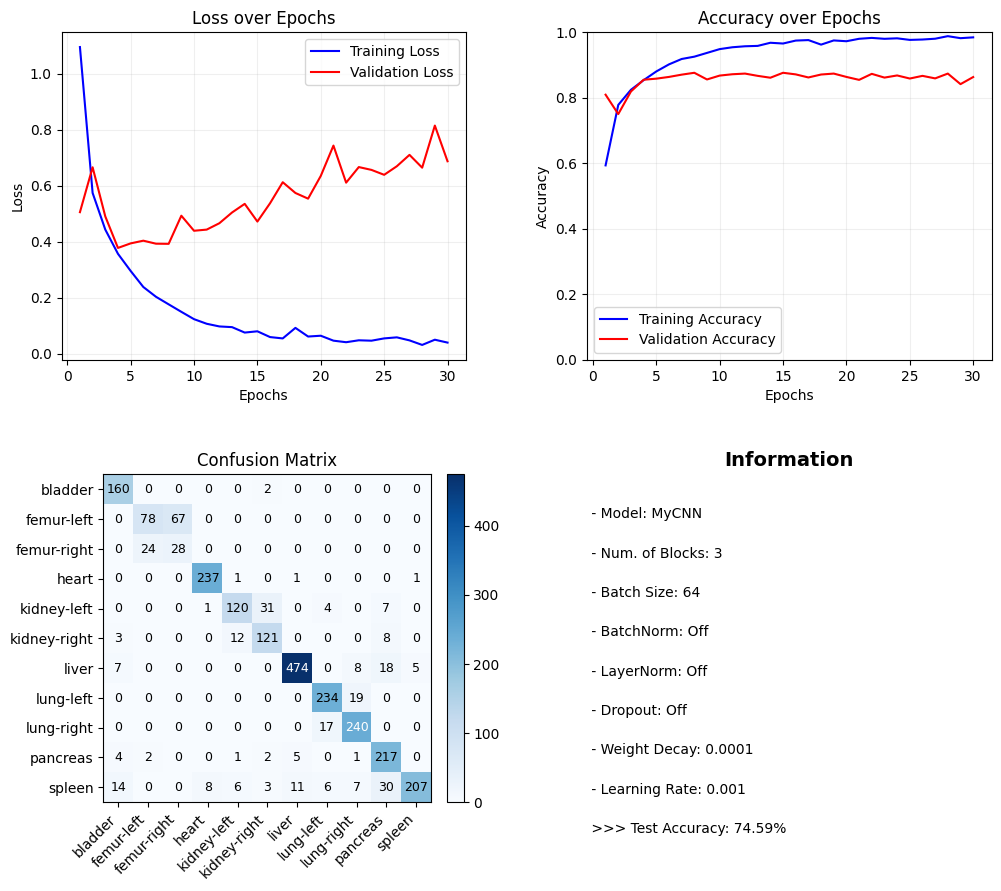

In [30]:
# Visualization
plot_loss_acc_confusion(train_losses_WD1, val_losses_WD1, train_accuracies_WD1, val_accuracies_WD1, test_acc_WD1,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, weight_decay=weight_decay)

#### IX. Weight Decay 2: 3 Blocks, learning rate: 1e-3, 30 Epochs, weight_decay: 1e-3 ####

In [31]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows  # square images

MyCNN_WD2 = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3)
MyCNN_WD2.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
weight_decay = 1e-3
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_WD2.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Initialize metrics lists
train_losses_WD2 = []
val_losses_WD2 = []
train_accuracies_WD2 = []
val_accuracies_WD2 = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_WD2, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_WD2, val_data, criterion, device)

    # Store metrics
    train_losses_WD2.append(train_loss)
    val_losses_WD2.append(val_loss)
    train_accuracies_WD2.append(train_acc)
    val_accuracies_WD2.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_WD2, _, _ = test_loop(MyCNN_WD2, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_WD2*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.1025, Train Acc: 59.08%
Val Loss: 0.5384, Val Acc: 79.08%

Epoch 5
-------------------------------
Train Loss: 0.3254, Train Acc: 86.76%
Val Loss: 0.4097, Val Acc: 85.44%

Epoch 10
-------------------------------
Train Loss: 0.1631, Train Acc: 93.27%
Val Loss: 0.3802, Val Acc: 87.11%

Epoch 15
-------------------------------
Train Loss: 0.1033, Train Acc: 96.05%
Val Loss: 0.4844, Val Acc: 84.54%

Epoch 20
-------------------------------
Train Loss: 0.0881, Train Acc: 96.47%
Val Loss: 0.4887, Val Acc: 86.09%

Epoch 25
-------------------------------
Train Loss: 0.0859, Train Acc: 96.68%
Val Loss: 0.4399, Val Acc: 87.15%

Epoch 30
-------------------------------
Train Loss: 0.0625, Train Acc: 97.62%
Val Loss: 0.4445, Val Acc: 86.66%

==================== Training complete ====================
>>> Test Accuracy: 73.63%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


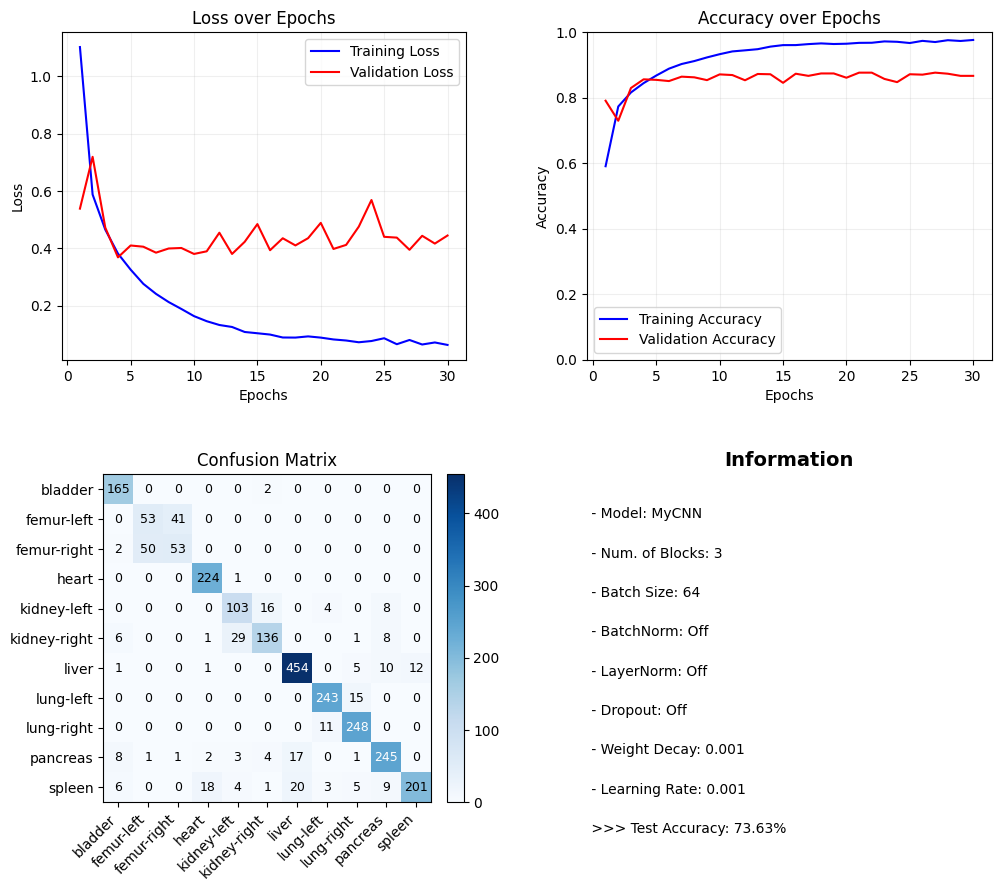

In [32]:
# Visualization
plot_loss_acc_confusion(train_losses_WD2, val_losses_WD2, train_accuracies_WD2, val_accuracies_WD2, test_acc_WD2,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, weight_decay=weight_decay)

#### X. Weight Decay 3: 3 Blocks, learning rate: 1e-3, 30 Epochs, weight_decay: 1e-2 ####

In [33]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows  # square images

MyCNN_WD3 = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3)
MyCNN_WD3.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
weight_decay = 1e-2
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_WD3.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Initialize metrics lists
train_losses_WD3 = []
val_losses_WD3 = []
train_accuracies_WD3 = []
val_accuracies_WD3 = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_WD3, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_WD3, val_data, criterion, device)

    # Store metrics
    train_losses_WD3.append(train_loss)
    val_losses_WD3.append(val_loss)
    train_accuracies_WD3.append(train_acc)
    val_accuracies_WD3.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_WD3, _, _ = test_loop(MyCNN_WD3, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_WD3*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.1772, Train Acc: 56.86%
Val Loss: 0.6308, Val Acc: 76.39%

Epoch 5
-------------------------------
Train Loss: 0.5040, Train Acc: 80.69%
Val Loss: 0.4569, Val Acc: 84.99%

Epoch 10
-------------------------------
Train Loss: 0.4034, Train Acc: 84.46%
Val Loss: 0.4349, Val Acc: 83.65%

Epoch 15
-------------------------------
Train Loss: 0.3533, Train Acc: 86.79%
Val Loss: 0.3961, Val Acc: 84.83%

Epoch 20
-------------------------------
Train Loss: 0.3306, Train Acc: 87.78%
Val Loss: 0.4065, Val Acc: 84.62%

Epoch 25
-------------------------------
Train Loss: 0.2991, Train Acc: 88.77%
Val Loss: 0.4246, Val Acc: 85.93%

Epoch 30
-------------------------------
Train Loss: 0.2848, Train Acc: 89.42%
Val Loss: 0.3818, Val Acc: 86.30%

==================== Training complete ====================
>>> Test Accuracy: 73.82%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


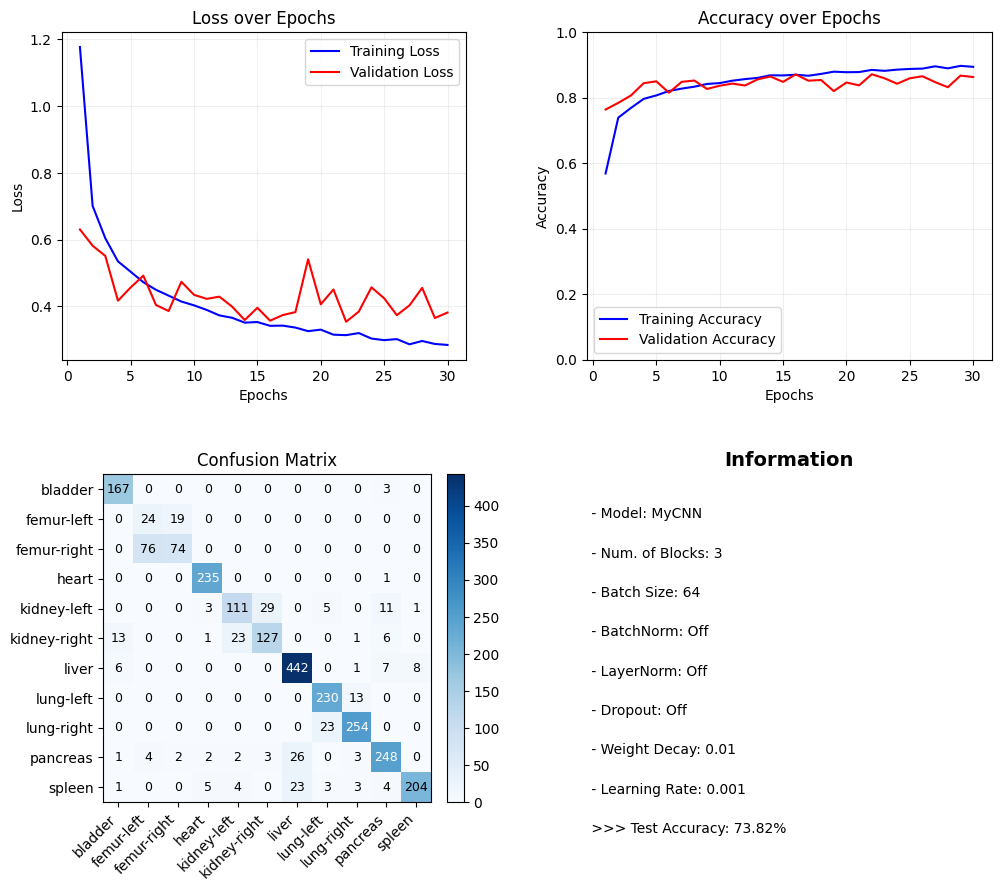

In [34]:
# Visualization
plot_loss_acc_confusion(train_losses_WD3, val_losses_WD3, train_accuracies_WD3, val_accuracies_WD3, test_acc_WD3,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, weight_decay=weight_decay)

#### XI. Batch Normalization + Dropout: 3 Blocks, learning rate: 1e-3, 30 Epochs, batch_norm: on, dropout_prob 70% ####

In [41]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows  # square images

MyCNN_BN_Drop = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3, batch_norm=True, 
                      dropout_prob=0.7) # 70% dropout chosen after testing with 20% (75.82% Test Acc) and 50% (77.43% Test Acc), 
                                        # as 70% gave the best Test Accuracy (77.90%)
MyCNN_BN_Drop.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_BN_Drop.parameters(), lr=learning_rate)

# Initialize metrics lists
train_losses_BN_Drop = []
val_losses_BN_Drop = []
train_accuracies_BN_Drop = []
val_accuracies_BN_Drop = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_BN_Drop, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_BN_Drop, val_data, criterion, device)

    # Store metrics
    train_losses_BN_Drop.append(train_loss)
    val_losses_BN_Drop.append(val_loss)
    train_accuracies_BN_Drop.append(train_acc)
    val_accuracies_BN_Drop.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_BN_Drop, _, _ = test_loop(MyCNN_BN_Drop, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_BN_Drop*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.0832, Train Acc: 61.16%
Val Loss: 0.5238, Val Acc: 77.12%

Epoch 5
-------------------------------
Train Loss: 0.4579, Train Acc: 81.62%
Val Loss: 0.3096, Val Acc: 87.44%

Epoch 10
-------------------------------
Train Loss: 0.3410, Train Acc: 85.92%
Val Loss: 0.2910, Val Acc: 88.42%

Epoch 15
-------------------------------
Train Loss: 0.2731, Train Acc: 88.57%
Val Loss: 0.2347, Val Acc: 90.66%

Epoch 20
-------------------------------
Train Loss: 0.2237, Train Acc: 90.67%
Val Loss: 0.2306, Val Acc: 90.74%

Epoch 25
-------------------------------
Train Loss: 0.1914, Train Acc: 92.13%
Val Loss: 0.2547, Val Acc: 89.72%

Epoch 30
-------------------------------
Train Loss: 0.1694, Train Acc: 92.69%
Val Loss: 0.2399, Val Acc: 90.13%

==================== Training complete ====================
>>> Test Accuracy: 77.91%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


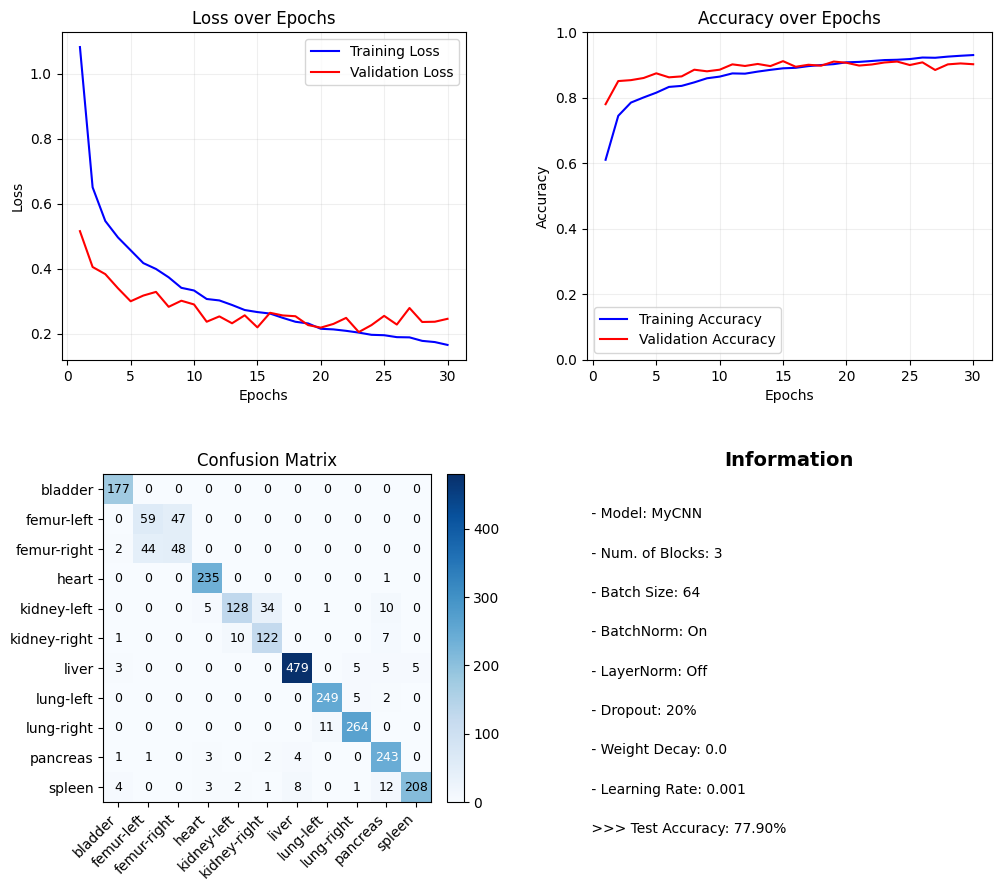

In [ ]:
# Visualization
plot_loss_acc_confusion(train_losses_BN_Drop, val_losses_BN_Drop, train_accuracies_BN_Drop, val_accuracies_BN_Drop, test_acc_BN_Drop,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, batch_norm=True, dropout=0.7)

#### XII. Batch Norm. + Layer Norm. + Dropout: 3 Blocks, learning rate: 1e-3, 30 Epochs, batch_norm: on, dropout_prob 70% ####

In [ ]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows  # square images

MyCNN_BN_LN_Drop = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3, batch_norm=True, 
                         layer_norm=True, dropout_prob=0.7) # 70% dropout chosen after testing with 20% (75.46% Test Acc) and 50% 
                                                            # (75.94% Test Acc), as 70% gave the best Test Accuracy (76.88%)
MyCNN_BN_LN_Drop.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_BN_LN_Drop.parameters(), lr=learning_rate)

# Initialize metrics lists
train_losses_BN_LN_Drop = []
val_losses_BN_LN_Drop = []
train_accuracies_BN_LN_Drop = []
val_accuracies_BN_LN_Drop = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_BN_LN_Drop, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_BN_LN_Drop, val_data, criterion, device)

    # Store metrics
    train_losses_BN_LN_Drop.append(train_loss)
    val_losses_BN_LN_Drop.append(val_loss)
    train_accuracies_BN_LN_Drop.append(train_acc)
    val_accuracies_BN_LN_Drop.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_BN_LN_Drop, _, _ = test_loop(MyCNN_BN_LN_Drop, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_BN_LN_Drop*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.7539, Train Acc: 41.33%
Val Loss: 0.8327, Val Acc: 73.45%

Epoch 5
-------------------------------
Train Loss: 0.6881, Train Acc: 74.93%
Val Loss: 0.3766, Val Acc: 86.87%

Epoch 10
-------------------------------
Train Loss: 0.4588, Train Acc: 82.68%
Val Loss: 0.2927, Val Acc: 88.74%

Epoch 15
-------------------------------
Train Loss: 0.3672, Train Acc: 85.92%
Val Loss: 0.2687, Val Acc: 89.11%

Epoch 20
-------------------------------
Train Loss: 0.2953, Train Acc: 88.58%
Val Loss: 0.2654, Val Acc: 88.95%

Epoch 25
-------------------------------
Train Loss: 0.2512, Train Acc: 90.27%
Val Loss: 0.2570, Val Acc: 89.31%

Epoch 30
-------------------------------
Train Loss: 0.2200, Train Acc: 91.48%
Val Loss: 0.2554, Val Acc: 89.52%

==================== Training complete ====================
>>> Test Accuracy: 76.02%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


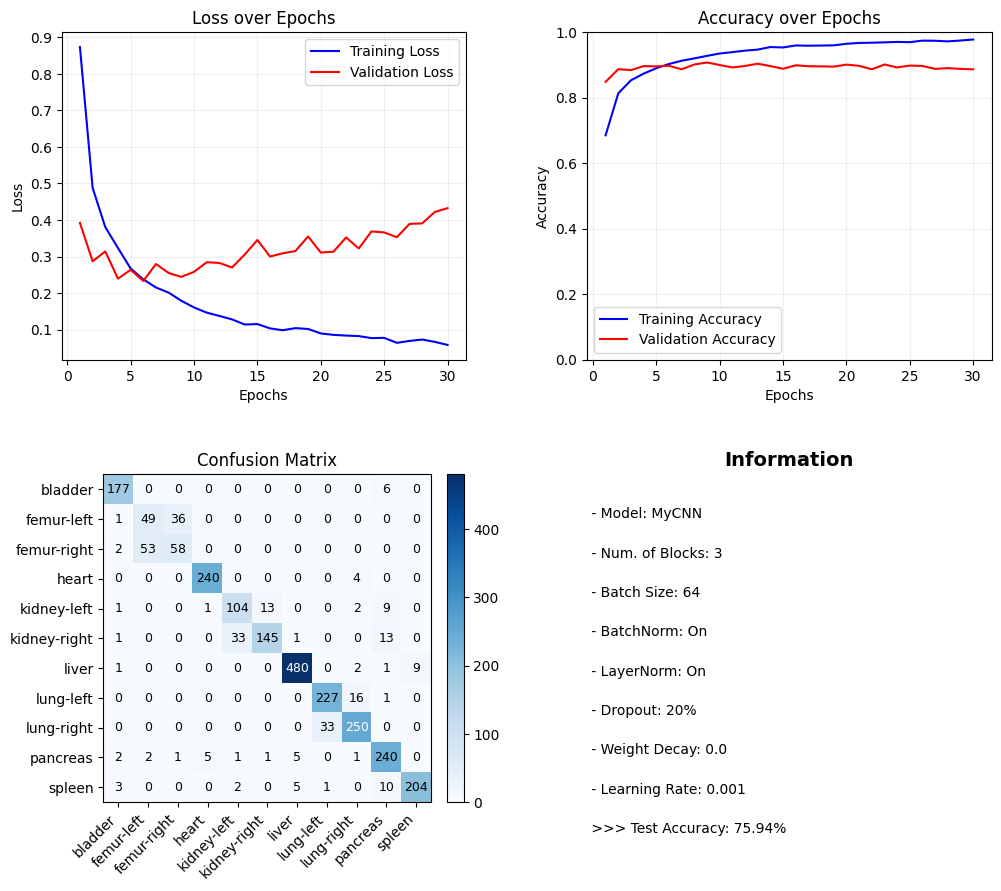

In [ ]:
# Visualization
plot_loss_acc_confusion(train_losses_BN_LN_Drop, val_losses_BN_LN_Drop, train_accuracies_BN_LN_Drop, val_accuracies_BN_LN_Drop, test_acc_BN_LN_Drop,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, batch_norm=True, layer_norm=True, dropout=0.7)

#### XIII. Batch Norm. + Dropout + Weight Decay: 3 Blocks, learning rate: 1e-3, 30 Epochs, batch_norm: on, dropout_prob: 70%, weight_decay: 1e-4 ####

In [48]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows  # square images

MyCNN_BN_Drop_WD = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3, 
                         batch_norm=True, dropout_prob=0.7)
MyCNN_BN_Drop_WD.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
weight_decay = 1e-4
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_BN_Drop_WD.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Initialize metrics lists
train_losses_BN_Drop_WD = []
val_losses_BN_Drop_WD = []
train_accuracies_BN_Drop_WD = []
val_accuracies_BN_Drop_WD = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_BN_Drop_WD, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_BN_Drop_WD, val_data, criterion, device)

    # Store metrics
    train_losses_BN_Drop_WD.append(train_loss)
    val_losses_BN_Drop_WD.append(val_loss)
    train_accuracies_BN_Drop_WD.append(train_acc)
    val_accuracies_BN_Drop_WD.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_BN_Drop_WD, _, _ = test_loop(MyCNN_BN_Drop_WD, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_BN_Drop_WD*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.0805, Train Acc: 61.18%
Val Loss: 0.5184, Val Acc: 78.30%

Epoch 5
-------------------------------
Train Loss: 0.4610, Train Acc: 81.16%
Val Loss: 0.2844, Val Acc: 88.50%

Epoch 10
-------------------------------
Train Loss: 0.3319, Train Acc: 86.29%
Val Loss: 0.3017, Val Acc: 87.48%

Epoch 15
-------------------------------
Train Loss: 0.2738, Train Acc: 88.77%
Val Loss: 0.2358, Val Acc: 90.54%

Epoch 20
-------------------------------
Train Loss: 0.2268, Train Acc: 90.44%
Val Loss: 0.2529, Val Acc: 89.64%

Epoch 25
-------------------------------
Train Loss: 0.1987, Train Acc: 91.58%
Val Loss: 0.2464, Val Acc: 90.33%

Epoch 30
-------------------------------
Train Loss: 0.1731, Train Acc: 92.96%
Val Loss: 0.2628, Val Acc: 90.09%

==================== Training complete ====================
>>> Test Accuracy: 77.14%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


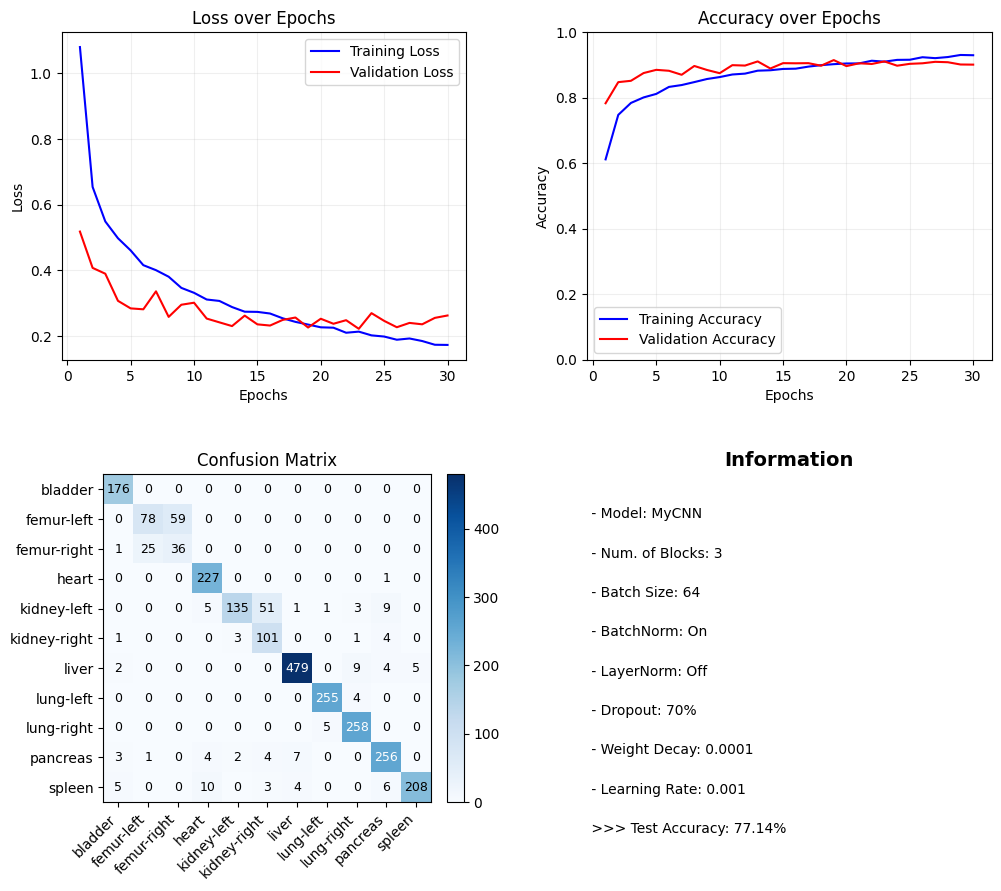

In [49]:
# Visualization
plot_loss_acc_confusion(train_losses_BN_Drop_WD, val_losses_BN_Drop_WD, train_accuracies_BN_Drop_WD, val_accuracies_BN_Drop_WD, test_acc_BN_Drop_WD,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, batch_norm=True, dropout=0.7, weight_decay=weight_decay)

#### XIV. Batch Norm. + Layer Norm. + Dropout + Weight Decay: dropout_prob: 70%, weight_decay: 1e-4 ####

In [50]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows  # square images

MyCNN_BN_LN_Drop_WD = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3, 
                            batch_norm=True, layer_norm=True, dropout_prob=0.7)
MyCNN_BN_LN_Drop_WD.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
weight_decay = 1e-4
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_BN_LN_Drop_WD.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Initialize metrics lists
train_losses_BN_LN_Drop_WD = []
val_losses_BN_LN_Drop_WD = []
train_accuracies_BN_LN_Drop_WD = []
val_accuracies_BN_LN_Drop_WD = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_BN_LN_Drop_WD, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_BN_LN_Drop_WD, val_data, criterion, device)

    # Store metrics
    train_losses_BN_LN_Drop_WD.append(train_loss)
    val_losses_BN_LN_Drop_WD.append(val_loss)
    train_accuracies_BN_LN_Drop_WD.append(train_acc)
    val_accuracies_BN_LN_Drop_WD.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_BN_LN_Drop_WD, _, _ = test_loop(MyCNN_BN_LN_Drop_WD, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_BN_LN_Drop_WD*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.0602, Train Acc: 62.72%
Val Loss: 0.3564, Val Acc: 86.13%

Epoch 5
-------------------------------
Train Loss: 0.4176, Train Acc: 83.23%
Val Loss: 0.2801, Val Acc: 89.36%

Epoch 10
-------------------------------
Train Loss: 0.2928, Train Acc: 88.01%
Val Loss: 0.2912, Val Acc: 88.05%

Epoch 15
-------------------------------
Train Loss: 0.2075, Train Acc: 91.44%
Val Loss: 0.2668, Val Acc: 89.56%

Epoch 20
-------------------------------
Train Loss: 0.1777, Train Acc: 92.61%
Val Loss: 0.2662, Val Acc: 90.21%

Epoch 25
-------------------------------
Train Loss: 0.1367, Train Acc: 94.39%
Val Loss: 0.2682, Val Acc: 90.46%

Epoch 30
-------------------------------
Train Loss: 0.1189, Train Acc: 95.06%
Val Loss: 0.3058, Val Acc: 89.40%

==================== Training complete ====================
>>> Test Accuracy: 75.69%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


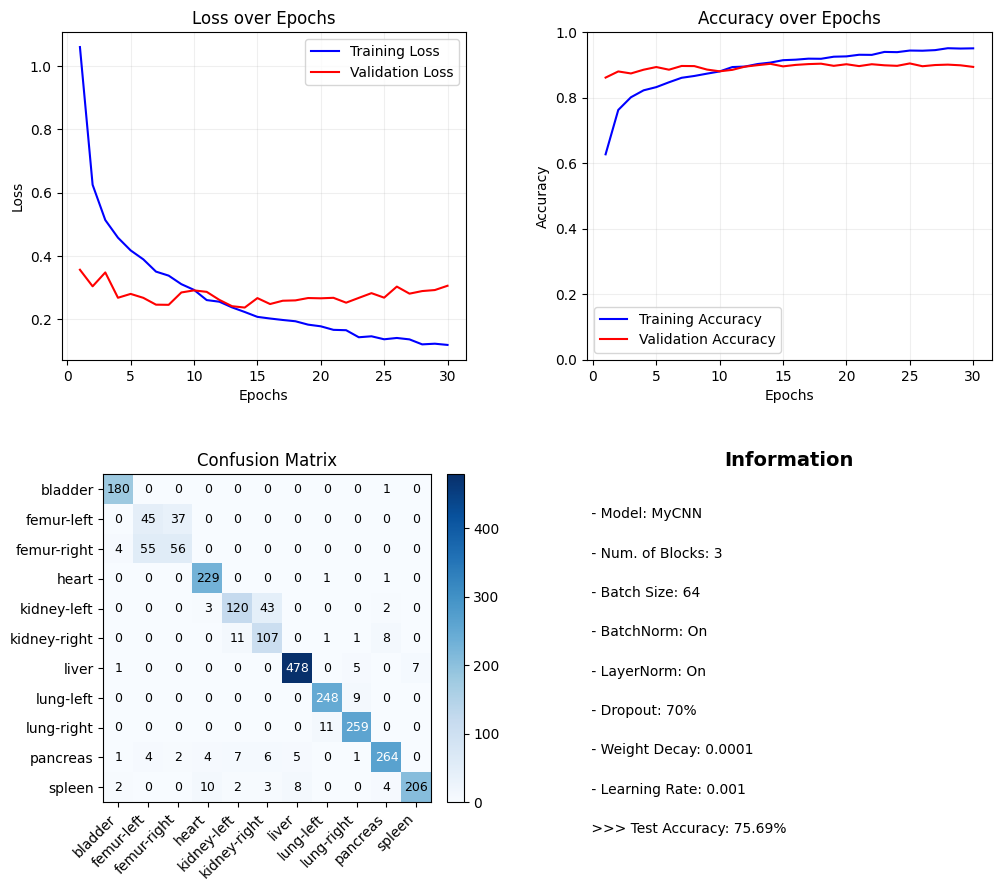

In [51]:
# Visualization
plot_loss_acc_confusion(train_losses_BN_LN_Drop_WD, val_losses_BN_LN_Drop_WD, train_accuracies_BN_LN_Drop_WD, val_accuracies_BN_LN_Drop_WD, test_acc_BN_LN_Drop_WD,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, batch_norm=True, 
                          layer_norm=True, dropout=0.7, weight_decay=weight_decay)

#### XV. Layer Norm. + Dropout: dropout_prob: 70% ####

In [52]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows  # square images

MyCNN_LN_Drop = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3, layer_norm=True, 
                      dropout_prob=0.7)
MyCNN_LN_Drop.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_LN_Drop.parameters(), lr=learning_rate)

# Initialize metrics lists
train_losses_LN_Drop = []
val_losses_LN_Drop = []
train_accuracies_LN_Drop = []
val_accuracies_LN_Drop = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_LN_Drop, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_LN_Drop, val_data, criterion, device)

    # Store metrics
    train_losses_LN_Drop.append(train_loss)
    val_losses_LN_Drop.append(val_loss)
    train_accuracies_LN_Drop.append(train_acc)
    val_accuracies_LN_Drop.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_LN_Drop, _, _ = test_loop(MyCNN_LN_Drop, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_LN_Drop*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.0800, Train Acc: 61.39%
Val Loss: 0.4250, Val Acc: 82.83%

Epoch 5
-------------------------------
Train Loss: 0.4056, Train Acc: 83.78%
Val Loss: 0.3486, Val Acc: 85.64%

Epoch 10
-------------------------------
Train Loss: 0.2409, Train Acc: 89.80%
Val Loss: 0.2765, Val Acc: 89.19%

Epoch 15
-------------------------------
Train Loss: 0.1886, Train Acc: 92.03%
Val Loss: 0.2473, Val Acc: 90.62%

Epoch 20
-------------------------------
Train Loss: 0.1487, Train Acc: 93.60%
Val Loss: 0.2800, Val Acc: 90.17%

Epoch 25
-------------------------------
Train Loss: 0.1270, Train Acc: 94.33%
Val Loss: 0.3083, Val Acc: 90.01%

Epoch 30
-------------------------------
Train Loss: 0.1178, Train Acc: 95.07%
Val Loss: 0.3196, Val Acc: 89.44%

==================== Training complete ====================
>>> Test Accuracy: 78.09%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


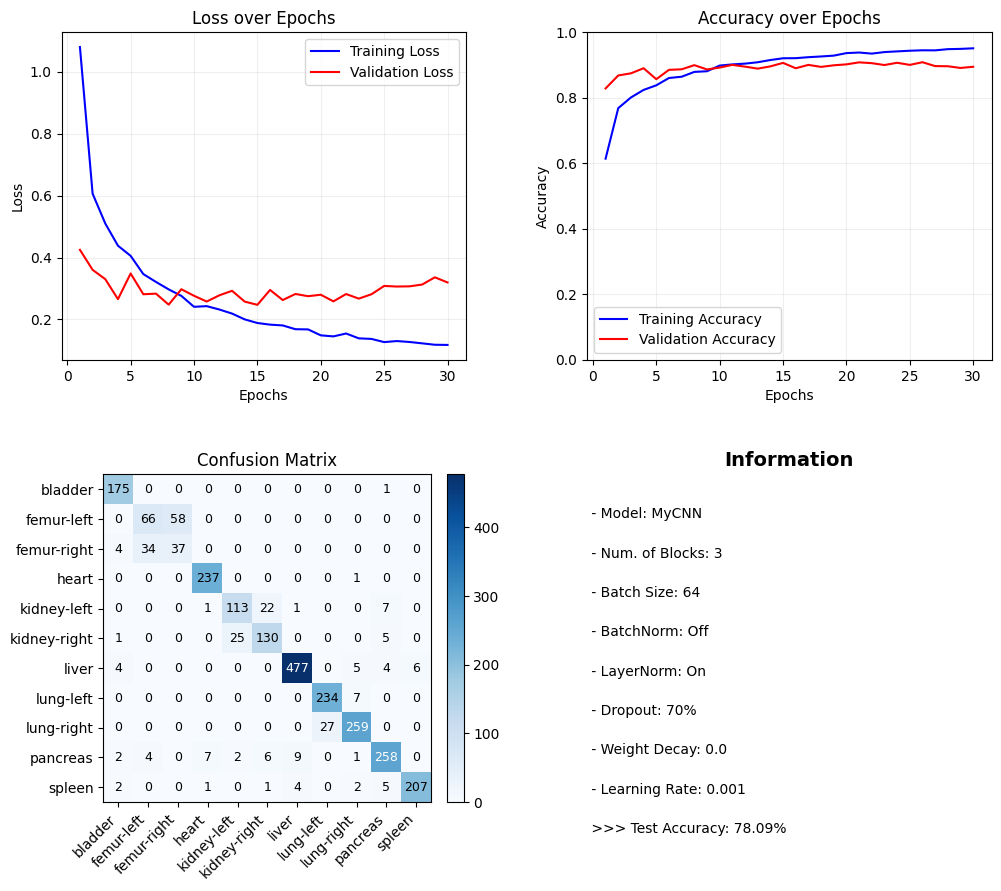

In [53]:
# Visualization
plot_loss_acc_confusion(train_losses_LN_Drop, val_losses_LN_Drop, train_accuracies_LN_Drop, val_accuracies_LN_Drop, test_acc_LN_Drop,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, num_of_blocks=3, layer_norm=True, dropout=0.7)

#### XVI. Layer Norm. + Dropout + Weight Decay: dropout_prob: 70%, weight_decay: 1e-4 ####

In [54]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows  # square images

MyCNN_LN_Drop_WD = MyCNN(img_size=img_size, num_of_channels=channels, num_of_classes=num_of_classes, num_of_blocks=3, layer_norm=True, 
                         dropout_prob=0.7)
MyCNN_LN_Drop_WD.to(device)

epochs = 30
learning_rate = 1e-3
batch_size = BATCH_SIZE
weight_decay = 1e-4
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_LN_Drop_WD.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Initialize metrics lists
train_losses_LN_Drop_WD = []
val_losses_LN_Drop_WD = []
train_accuracies_LN_Drop_WD = []
val_accuracies_LN_Drop_WD = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_LN_Drop_WD, train_data, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_LN_Drop_WD, val_data, criterion, device)

    # Store metrics
    train_losses_LN_Drop_WD.append(train_loss)
    val_losses_LN_Drop_WD.append(val_loss)
    train_accuracies_LN_Drop_WD.append(train_acc)
    val_accuracies_LN_Drop_WD.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_LN_Drop_WD, _, _ = test_loop(MyCNN_LN_Drop_WD, test_data, criterion, device)
print(f">>> Test Accuracy: {test_acc_LN_Drop_WD*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.0773, Train Acc: 61.50%
Val Loss: 0.4240, Val Acc: 82.99%

Epoch 5
-------------------------------
Train Loss: 0.3934, Train Acc: 83.95%
Val Loss: 0.3431, Val Acc: 86.30%

Epoch 10
-------------------------------
Train Loss: 0.2433, Train Acc: 89.92%
Val Loss: 0.2693, Val Acc: 88.62%

Epoch 15
-------------------------------
Train Loss: 0.1711, Train Acc: 92.43%
Val Loss: 0.2546, Val Acc: 90.21%

Epoch 20
-------------------------------
Train Loss: 0.1467, Train Acc: 93.58%
Val Loss: 0.2454, Val Acc: 91.23%

Epoch 25
-------------------------------
Train Loss: 0.1220, Train Acc: 94.72%
Val Loss: 0.3059, Val Acc: 90.01%

Epoch 30
-------------------------------
Train Loss: 0.1026, Train Acc: 95.68%
Val Loss: 0.3083, Val Acc: 89.85%

==================== Training complete ====================
>>> Test Accuracy: 76.74%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


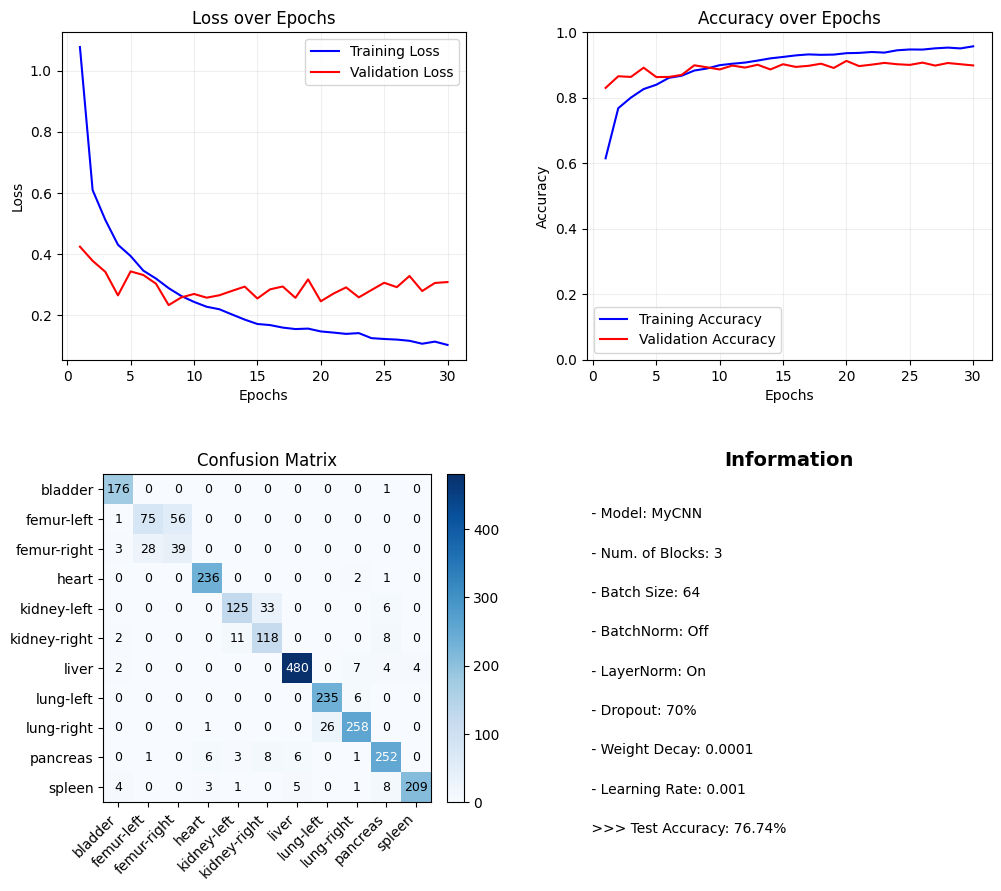

In [55]:
# Visualization
plot_loss_acc_confusion(train_losses_LN_Drop_WD, val_losses_LN_Drop_WD, train_accuracies_LN_Drop_WD, val_accuracies_LN_Drop_WD, test_acc_LN_Drop_WD,
                          targets, preds, labels_dict, model_name="MyCNN", batch_size=batch_size, learning_rate=learning_rate, 
                          num_of_blocks=3, layer_norm=True, dropout=0.7, weight_decay=weight_decay)

### 1.3 Additional Training Techniques ###

#### I. Data Augmentation ####

In [66]:
from torchvision import transforms

# Define image to tensor transform + data augmentation
data_transform_aug = transforms.Compose([
    # augmetation
    # transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=None),

    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5]) 
])

# Setup training, validation, and test datasets
train_dataset_aug = OrganSMNIST(split="train", download=True, transform=data_transform_aug)
val_dataset_aug = OrganSMNIST(split="val", download=True, transform=data_transform_aug)
test_dataset_aug = OrganSMNIST(split="test", download=True, transform=data_transform_aug)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 64
torch.manual_seed(42) 
train_data_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
val_data_aug = DataLoader(val_dataset_aug, batch_size=BATCH_SIZE, shuffle=False)
test_data_aug = DataLoader(test_dataset_aug, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# setup device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
torch.manual_seed(42)

img_size = rows  # square images

MyCNN_LN_Drop = MyCNN(img_size=img_size, num_of_channels=channels, num_of_filters=64, num_of_classes=num_of_classes, num_of_blocks=3, 
                      batch_norm=True, dropout_prob=0.5)
MyCNN_LN_Drop.to(device)

epochs = 40
learning_rate = 1e-3
batch_size = BATCH_SIZE
weight_decay = 1e-4
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(MyCNN_LN_Drop.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)

# Initialize metrics lists
train_losses_LN_Drop_AUG = []
val_losses_LN_Drop_AUG = []
train_accuracies_LN_Drop_AUG = []
val_accuracies_LN_Drop_AUG = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(MyCNN_LN_Drop, train_data_aug, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(MyCNN_LN_Drop, val_data_aug, criterion, device)

    # Store metrics
    train_losses_LN_Drop_AUG.append(train_loss)
    val_losses_LN_Drop_AUG.append(val_loss)
    train_accuracies_LN_Drop_AUG.append(train_acc)
    val_accuracies_LN_Drop_AUG.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_LN_Drop_AUG, _, _ = test_loop(MyCNN_LN_Drop, test_data_aug, criterion, device)
print(f">>> Test Accuracy: {test_acc_LN_Drop_AUG*100:.2f}%")

Using device: cuda
==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 1.0718, Train Acc: 60.49%
Val Loss: 0.5259, Val Acc: 78.71%

Epoch 5
-------------------------------
Train Loss: 0.5441, Train Acc: 78.49%
Val Loss: 0.3664, Val Acc: 85.44%

Epoch 10
-------------------------------
Train Loss: 0.4157, Train Acc: 83.13%
Val Loss: 0.3480, Val Acc: 85.73%

Epoch 15
-------------------------------
Train Loss: 0.3619, Train Acc: 85.05%
Val Loss: 0.3718, Val Acc: 85.60%

Epoch 20
-------------------------------
Train Loss: 0.3205, Train Acc: 86.99%
Val Loss: 0.3470, Val Acc: 86.87%

Epoch 25
-------------------------------
Train Loss: 0.2808, Train Acc: 88.34%
Val Loss: 0.3268, Val Acc: 87.97%

Epoch 30
-------------------------------
Train Loss: 0.2584, Train Acc: 89.04%
Val Loss: 0.3631, Val Acc: 86.83%

Epoch 35
-------------------------------
Train Loss: 0.2412, Train Acc: 89.98%
Val Loss: 0.2795, Val Acc: 89.03%

Epoch 40
--

/tmp/ipython-input-4030518770.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


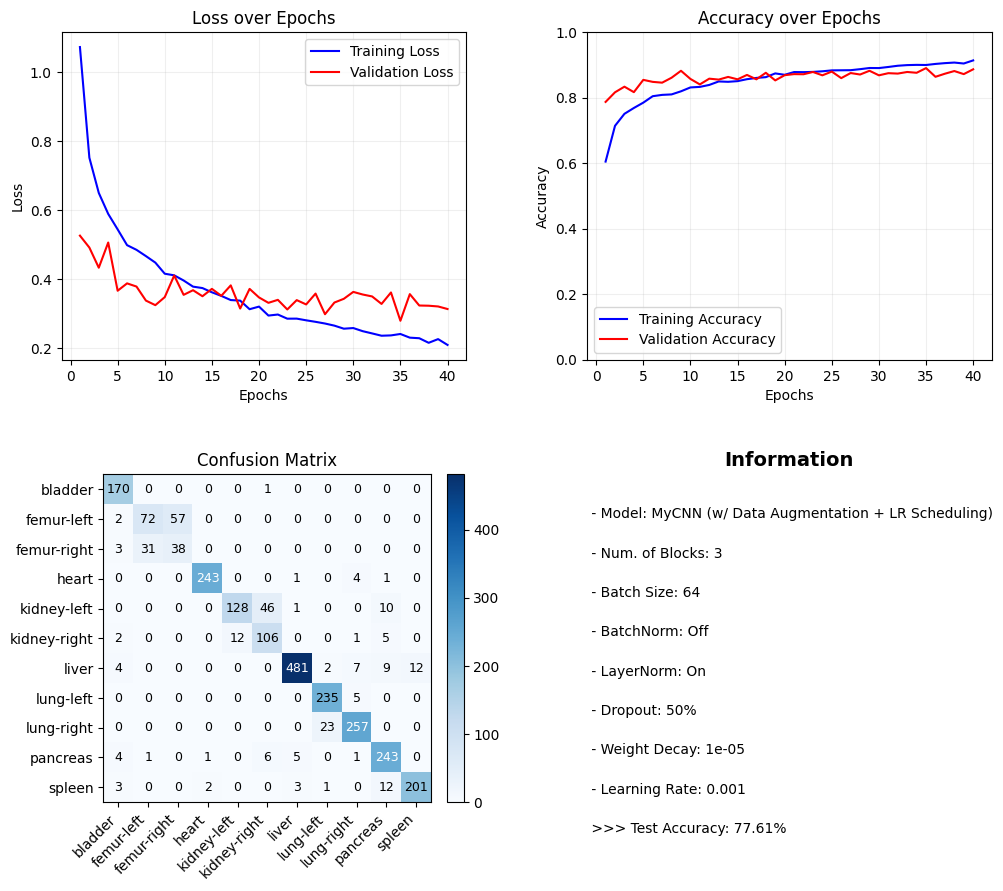

In [85]:
# Visualization
plot_loss_acc_confusion(train_losses_LN_Drop_AUG, val_losses_LN_Drop_AUG, train_accuracies_LN_Drop_AUG, val_accuracies_LN_Drop_AUG, test_acc_LN_Drop_AUG,
                          targets, preds, labels_dict, model_name="MyCNN (w/ Data Augmentation + LR Scheduling)", batch_size=batch_size, learning_rate=learning_rate, 
                          num_of_blocks=3, layer_norm=True, dropout=0.5, weight_decay=weight_decay)

## **2.** CNN utilizing Transfer Learning ##

### 2.1 Feature Extraction ###

In [74]:
import torch
import torch.nn as nn
from torchvision import models

# Setup ResNet18 for feature extraction
resNet18_FE = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in resNet18_FE.parameters():
    param.requires_grad = False

# Get output features and add fully connected layer
num_features = resNet18_FE.fc.in_features
resNet18_FE.fc = nn.Linear(num_features, num_of_classes)

# Unfreeze the fully connected layer
for param in resNet18_FE.fc.parameters():
    param.requires_grad = True

resNet18_FE = resNet18_FE.to(device)

#### Classifier head training: Adam Optimizer, learning rate: 1e-3, Batch size: 64, 20 Epochs ####

In [77]:
# Define image to tensor transform 
data_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet18 expects 224x224 input
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset_224 = OrganSMNIST(split="train", download=True, transform=data_transform_224)
val_dataset_224 = OrganSMNIST(split="val", download=True, transform=data_transform_224)
test_dataset_224 = OrganSMNIST(split="test", download=True, transform=data_transform_224)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 64
torch.manual_seed(42) 
train_data_224 = DataLoader(train_dataset_224, batch_size=BATCH_SIZE, shuffle=True)
val_data_224 = DataLoader(val_dataset_224, batch_size=BATCH_SIZE, shuffle=False)
test_data_224 = DataLoader(test_dataset_224, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
epochs = 20
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resNet18_FE.parameters(), lr=learning_rate)

# Initialize metrix lists
train_losses_resNet18_FE = []
val_losses_resNet18_FE = []
train_accuracies_resNet18_FE = []
val_accuracies_resNet18_FE = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(resNet18_FE, train_data_224, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(resNet18_FE, val_data_224, criterion, device)

    # Store metrics
    train_losses_resNet18_FE.append(train_loss)
    val_losses_resNet18_FE.append(val_loss)
    train_accuracies_resNet18_FE.append(train_acc)
    val_accuracies_resNet18_FE.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_resNet18_FE, _, _ = test_loop(resNet18_FE, test_data_224, criterion, device)
print(f">>> Test Accuracy: {test_acc_resNet18_FE*100:.2f}%")

/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


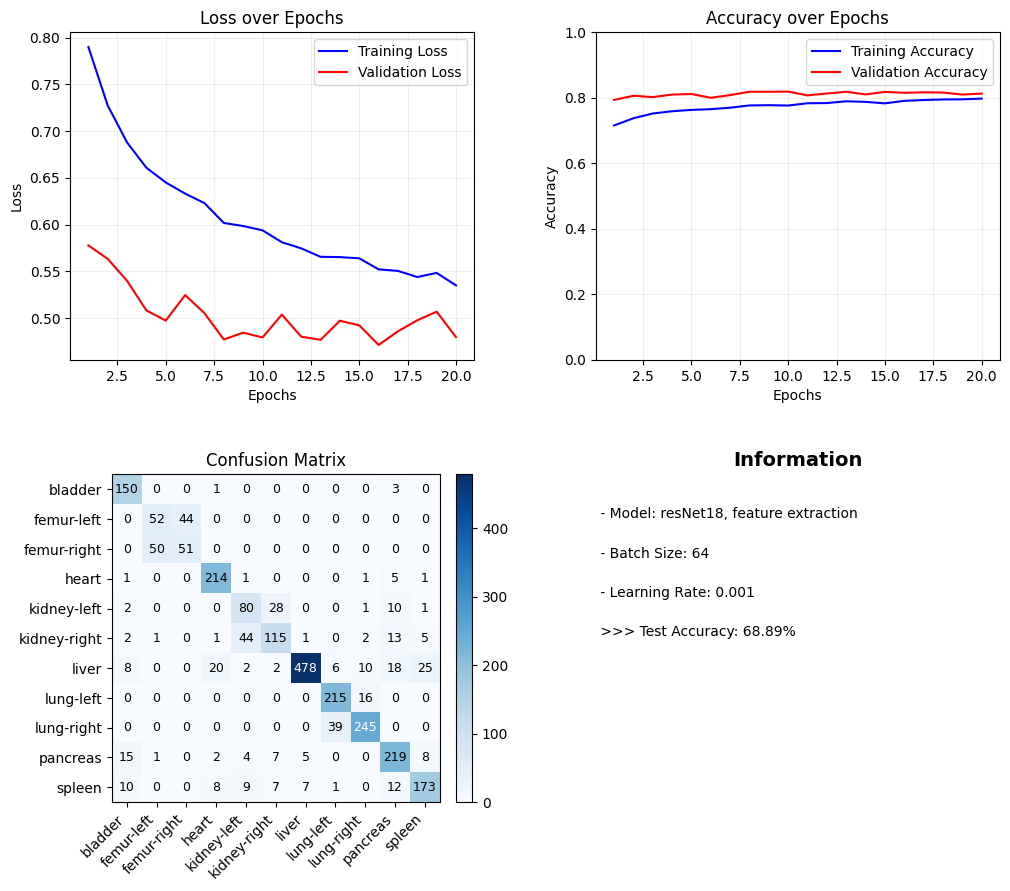

In [ ]:
# Visualization
plot_loss_acc_confusion(train_losses_resNet18_FE, val_losses_resNet18_FE, train_accuracies_resNet18_FE, val_accuracies_resNet18_FE, test_acc_resNet18_FE,
                          targets, preds, labels_dict,"resNet18, Feature extraction", batch_size, learning_rate)

### 2.2 Fine-Tuning ###

In [86]:
import torch
import torch.nn as nn
from torchvision import models

# Setup ResNet18 for fine-tuning
resNet18_FT = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
#print(resNet18_FT)

# Freeze all layers
for param in resNet18_FT.parameters():
    param.requires_grad = False

# Get output features and add fully connected layer
num_features = resNet18_FT.fc.in_features
resNet18_FT.fc = nn.Linear(num_features, num_of_classes)

# Unfreeze the fully connected layer
for param in resNet18_FT.fc.parameters():
    param.requires_grad = True

# Unfreeze last two blocks
for param in resNet18_FT.layer4.parameters(): # last 2 blocks: BasikBlock0 and BasicBlock1 in layer4
    param.requires_grad = True    

resNet18_FT = resNet18_FT.to(device)

#### Classifier head and last 2 blocks training: Adam Optimizer, learning rate: 1e-4, Batch size: 32, 12 Epochs ####

In [ ]:
# Define image to tensor transform 
data_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),  # ResNet18 expects 224x224 input
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset_224 = OrganSMNIST(split="train", download=True, transform=data_transform_224)
val_dataset_224 = OrganSMNIST(split="val", download=True, transform=data_transform_224)
test_dataset_224 = OrganSMNIST(split="test", download=True, transform=data_transform_224)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 32
torch.manual_seed(42) 
train_data_224 = DataLoader(train_dataset_224, batch_size=BATCH_SIZE, shuffle=True)
val_data_224 = DataLoader(val_dataset_224, batch_size=BATCH_SIZE, shuffle=False)
test_data_224 = DataLoader(test_dataset_224, batch_size=BATCH_SIZE, shuffle=False)

In [102]:
epochs = 12
learning_rate = 1e-4
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resNet18_FT.parameters(), lr=learning_rate)

# Initialize metrix lists
train_losses_resNet18_FT = []
val_losses_resNet18_FT = []
train_accuracies_resNet18_FT = []
val_accuracies_resNet18_FT = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(resNet18_FT, train_data_224, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(resNet18_FT, val_data_224, criterion, device)

    # Store metrics
    train_losses_resNet18_FT.append(train_loss)
    val_losses_resNet18_FT.append(val_loss)
    train_accuracies_resNet18_FT.append(train_acc)
    val_accuracies_resNet18_FT.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_resNet18_FT, _, _ = test_loop(resNet18_FT, test_data_224, criterion, device)
print(f">>> Test Accuracy: {test_acc_resNet18_FT*100:.2f}%")

In [88]:
# Visualization
plot_loss_acc_confusion(train_losses_resNet18_FT, val_losses_resNet18_FT, train_accuracies_resNet18_FT, val_accuracies_resNet18_FT, test_acc_resNet18_FT,
                          targets, preds, labels_dict,"resNet18, Fine-Tuning", batch_size, learning_rate)

## **3.** Small Vision Transformer (DeiT) ##

### 3.1 Feature Extraction ###

In [ ]:
import timm

# Set up DeiT-Tiny
DeiT = timm.create_model(
    "deit_tiny_patch16_224",
    pretrained=True,
    num_classes=num_of_classes
).to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

#### Classifier head training: Adam optimizer, learning rate: 1e-3. Batch size: 32, 12 Epochs #### 

In [ ]:
# Define image to tensor transform 
data_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),  # DeiT expects 224x224 input
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset_224 = OrganSMNIST(split="train", download=True, transform=data_transform_224)
val_dataset_224 = OrganSMNIST(split="val", download=True, transform=data_transform_224)
test_dataset_224 = OrganSMNIST(split="test", download=True, transform=data_transform_224)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 32
torch.manual_seed(42) 
train_data_224 = DataLoader(train_dataset_224, batch_size=BATCH_SIZE, shuffle=True)
val_data_224 = DataLoader(val_dataset_224, batch_size=BATCH_SIZE, shuffle=False)
test_data_224 = DataLoader(test_dataset_224, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
epochs = 12
learning_rate = 1e-3
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(DeiT.head.parameters(), lr=learning_rate)

# Initialize metrix lists
train_losses_Deit_FE = []
val_losses_Deit_FE = []
train_accuracies_Deit_FE = []
val_accuracies_Deit_FE = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(DeiT, train_data_224, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(DeiT, val_data_224, criterion, device)

    # Store metrics
    train_losses_Deit_FE.append(train_loss)
    val_losses_Deit_FE.append(val_loss)
    train_accuracies_Deit_FE.append(train_acc)
    val_accuracies_Deit_FE.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_Deit_FE, _, _ = test_loop(DeiT, test_data_224, criterion, device)
print(f">>> Test Accuracy: {test_acc_Deit_FE*100:.2f}%")

==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 2.0726, Train Acc: 26.77%
Val Loss: 1.8404, Val Acc: 31.65%

Epoch 5
-------------------------------
Train Loss: 1.1593, Train Acc: 64.59%
Val Loss: 1.0005, Val Acc: 70.60%

Epoch 10
-------------------------------
Train Loss: 0.9119, Train Acc: 70.08%
Val Loss: 0.7601, Val Acc: 76.51%

==================== Training complete ====================
>>> Test Accuracy: 65.50%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


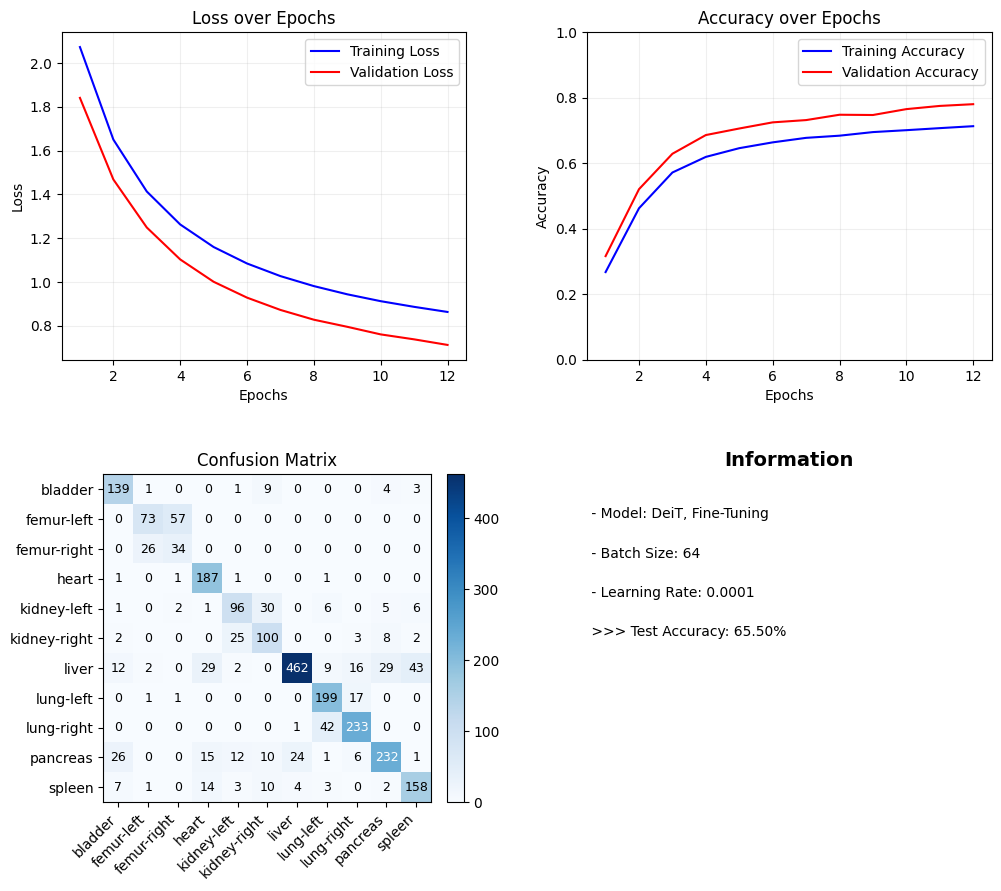

In [93]:
# Visualization
plot_loss_acc_confusion(train_losses_Deit_FE, val_losses_Deit_FE, train_accuracies_Deit_FE, val_accuracies_Deit_FE, test_acc_Deit_FE,
                          targets, preds, labels_dict,"DeiT, Fine-Tuning", batch_size, learning_rate)

### 3.2 Fine-Tuning ###

In [95]:
import timm

# Set up DeiT-Tiny for fine-tuning
DeiT_FT = timm.create_model(
    "deit_tiny_patch16_224",
    pretrained=True,
    num_classes=num_of_classes
).to(device)

# Freeze all layers 
for param in DeiT_FT.parameters():
    param.requires_grad = False

# Unfreeze the classifier head
for param in DeiT_FT.head.parameters():
    param.requires_grad = True

# Unfreeze last transformer block
for param in DeiT_FT.blocks[-1].parameters(): 
    param.requires_grad = True

DeiT_FT = DeiT_FT.to(device)

#### Classifier head and last transformer block training: Adam optimizer, learning rate: 1e-4. Batch size: 16, 7 Epochs #### 

In [96]:
# Define image to tensor transform 
data_transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),  # DeiT expects 224x224 input
    transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset_224 = OrganSMNIST(split="train", download=True, transform=data_transform_224)
val_dataset_224 = OrganSMNIST(split="val", download=True, transform=data_transform_224)
test_dataset_224 = OrganSMNIST(split="test", download=True, transform=data_transform_224)

# Dataloader 
from torch.utils.data import DataLoader
BATCH_SIZE = 16
torch.manual_seed(42) 
train_data_224 = DataLoader(train_dataset_224, batch_size=BATCH_SIZE, shuffle=True)
val_data_224 = DataLoader(val_dataset_224, batch_size=BATCH_SIZE, shuffle=False)
test_data_224 = DataLoader(test_dataset_224, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
epochs = 7
learning_rate = 1e-4
batch_size = BATCH_SIZE
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(DeiT_FT.parameters(), lr=learning_rate)

# Initialize metrix lists
train_losses_Deit_FT = []
val_losses_Deit_FT = []
train_accuracies_Deit_FT = []
val_accuracies_Deit_FT = []

print(f"==================== Starting Training ====================")
for epoch in range(epochs):
    train_loss, train_acc = train_loop(DeiT_FT, train_data_224, optimizer, criterion, device)
    val_loss, val_acc, targets, preds = test_loop(DeiT, val_data_224, criterion, device)

    # Store metrics
    train_losses_Deit_FT.append(train_loss)
    val_losses_Deit_FT.append(val_loss)
    train_accuracies_Deit_FT.append(train_acc)
    val_accuracies_Deit_FT.append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch+1}\n-------------------------------")
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%\n")

print("==================== Training complete ====================")

_, test_acc_Deit_FT, _, _ = test_loop(DeiT_FT, test_data_224, criterion, device)
print(f">>> Test Accuracy: {test_acc_Deit_FT*100:.2f}%")

==================== Starting Training ====================
Epoch 1
-------------------------------
Train Loss: 0.1111, Train Acc: 95.20%
Val Loss: 0.7114, Val Acc: 78.02%

Epoch 5
-------------------------------
Train Loss: 0.0549, Train Acc: 97.49%
Val Loss: 0.7114, Val Acc: 78.02%

==================== Training complete ====================
>>> Test Accuracy: 72.71%


/tmp/ipython-input-1764412135.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


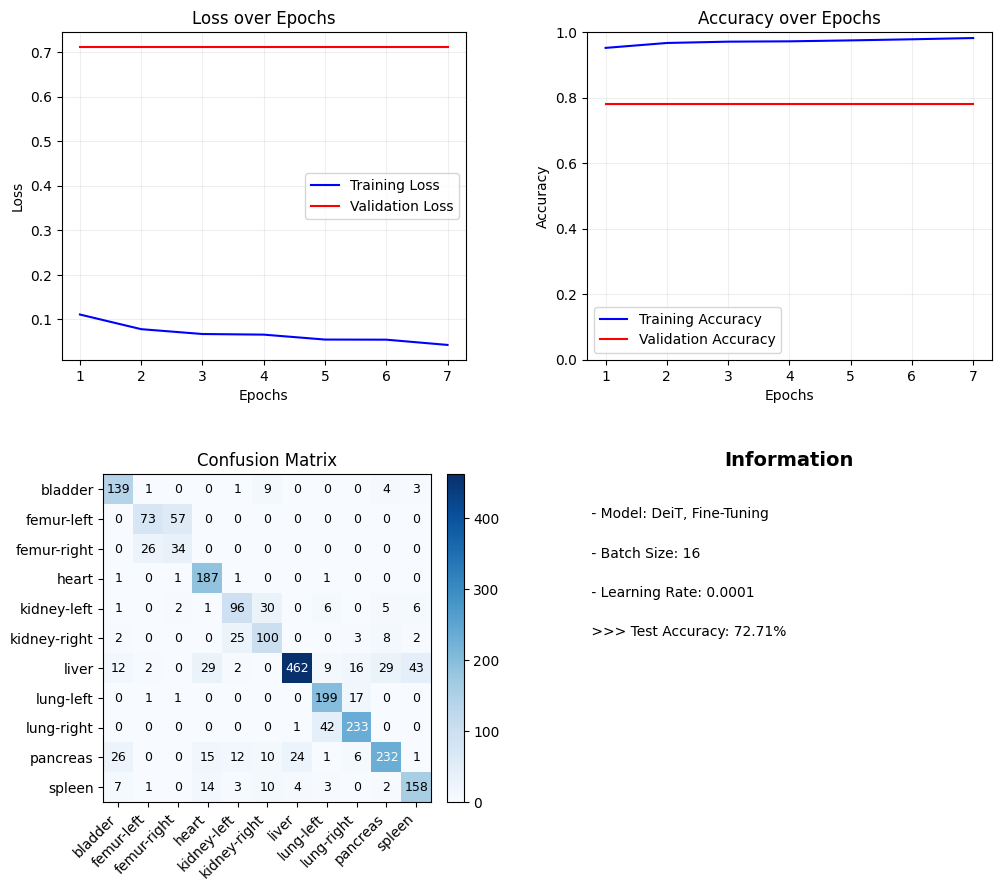

In [100]:
# Visualization
plot_loss_acc_confusion(train_losses_Deit_FT, val_losses_Deit_FT, train_accuracies_Deit_FT, val_accuracies_Deit_FT, test_acc_Deit_FT,
                          targets, preds, labels_dict,"DeiT, Fine-Tuning", batch_size, learning_rate)